# Microbiology Events Code

##### This Python Notebook is dedicated to - "microbiology_events_codes_3.csv" Dataset.

-----------------------------------------

## Event Flow for the Notebook

#### 0. Library Imports
- Import all required Python libraries such as pandas, numpy, matplotlib, seaborn, etc.

#### 1. Data Collection Phase (Data Import)
- Load `microbiology_events_codes_3.csv`
- Display first few rows  
- Keep a copy of the original dataset  

#### 1.1 Initial Data Exploration
- Check column names  
- View datatypes  
- Display dataframe info  
- Check dataset size (rows & columns)  
- Inspect unique values of each column  

#### 2. Null Values & Missing Data Analysis
- Count missing values per column  
- Calculate missing value percentages  
- Visualize missingness patterns  

#### 3. Descriptive Statistics
- Numerical summary (mean, median, etc.)  
- Value counts for categorical columns  
- Distribution plots (histograms)

#### 4. Dilution Value Analysis (Outliers)
- Check distribution of `dilution_value`  
- Identify outliers  
- Visualize with subplots  
- Decide whether to remove extremely high dilution values  

#### 5. String-column Cleaning & Validation
- Identify all string columns  
- Preview whitespace and casing inconsistencies  
- Detect leading/trailing spaces  
- Verify case normalization  
- Validate `dilution_comparison` symbols  
- Validate microbiology interpretation labels  



------------------------------------

#### 0. Library Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from matplotlib.ticker import PercentFormatter

#### 1. Data Collection Phase (Data import)

In [2]:
df = pd.read_csv('microbiology_events_codes_3.csv')

In [3]:
# Checking the first 3 rows of the dataframe.
# This confirms that the data has been loaded correctly. 
df.head(3)

,subject_id,hadm_id,chartdate,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_text,dilution_comparison,dilution_value,interpretation,technician_id,qc_flag
0,10000980,26913865.0,2189-06-27 00:00:00,2189-06-27 10:52:00,MRSA SCREEN,MRSA SCREEN,NaN,NaN,NaN,NaN,NaN,NaN,TECH_063,QC_OK
1,10002155,23822395.0,2129-08-04 00:00:00,2129-08-04 17:04:00,MRSA SCREEN,MRSA SCREEN,NaN,NaN,NaN,NaN,NaN,NaN,TECH_095,QC_OK
2,10002155,23822395.0,2129-08-05 00:00:00,2129-08-05 15:54:00,URINE,Legionella Urinary Antigen,NaN,NaN,NaN,NaN,NaN,NaN,TECH_083,QC_OK


In [4]:
# Keeping a copy of the original dataset for reference
original_dataset = df.copy()

##### 1.1 Initial Data Exploration

In [5]:
# Checking the column names of the dataframe
df.columns

Index(['subject_id', 'hadm_id', 'chartdate', 'charttime', 'spec_type_desc',
       'test_name', 'org_name', 'ab_name', 'dilution_text',
       'dilution_comparison', 'dilution_value', 'interpretation',
       'technician_id', 'qc_flag'],
      dtype='object')

In [6]:
df.dtypes

subject_id               int64
hadm_id                float64
chartdate               object
charttime               object
spec_type_desc          object
test_name               object
org_name                object
ab_name                 object
dilution_text           object
dilution_comparison     object
dilution_value         float64
interpretation          object
technician_id           object
qc_flag                 object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15587 entries, 0 to 15586
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   subject_id           15587 non-null  int64  
 1   hadm_id              15587 non-null  float64
 2   chartdate            15587 non-null  object 
 3   charttime            15587 non-null  object 
 4   spec_type_desc       15587 non-null  object 
 5   test_name            15587 non-null  object 
 6   org_name             5391 non-null   object 
 7   ab_name              4820 non-null   object 
 8   dilution_text        4713 non-null   object 
 9   dilution_comparison  4711 non-null   object 
 10  dilution_value       4711 non-null   float64
 11  interpretation       4820 non-null   object 
 12  technician_id        15587 non-null  object 
 13  qc_flag              15587 non-null  object 
dtypes: float64(2), int64(1), object(11)
memory usage: 1.7+ MB


##### ↑ We notice that total rows were: 15587, out of which some columns have nulls.

##### Now, checking the Data Distribution and overall look of the dataset

In [8]:
df.describe(include='all')

,subject_id,hadm_id,chartdate,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_text,dilution_comparison,dilution_value,interpretation,technician_id,qc_flag
count,1.558700e+04,1.558700e+04,15587,15587,15587,15587,5391,4820,4713,4711,4711.000000,4820,15587,15587
unique,NaN,NaN,4648,7709,42,90,82,27,32,3,NaN,3,120,3
top,NaN,NaN,2185-01-09 00:00:00,2185-01-09 10:55:00,URINE,URINE CULTURE,ESCHERICHIA COLI,GENTAMICIN,<=1,<=,NaN,S,TECH_037,QC_OK
freq,NaN,NaN,48,34,4951,4795,1508,453,1454,3233,NaN,3807,172,13236
mean,1.522098e+07,2.503469e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.062420,NaN,NaN,NaN
std,2.910238e+06,2.846364e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.245298,NaN,NaN,NaN
min,1.000098e+07,2.000790e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.060000,NaN,NaN,NaN
25%,1.266277e+07,2.266346e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,NaN,NaN,NaN
50%,1.519823e+07,2.514649e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
75%,1.772189e+07,2.743116e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN


#### Checking how each column looks specifically (their unique values vs its count)

In [9]:
for i in df.columns:
    print(df[i].value_counts())

subject_id
12492737    122
13135946    107
11204646     89
15016682     83
16571922     73
           ... 
15697529      1
15692859      1
15686320      1
15681388      1
19997669      1
Name: count, Length: 2616, dtype: int64
hadm_id
27261448.0    124
22133572.0    107
29675270.0     86
25177313.0     84
21332395.0     66
             ... 
26541852.0      1
20021932.0      1
29836403.0      1
23742800.0      1
28574336.0      1
Name: count, Length: 2454, dtype: int64
chartdate
2185-01-09 00:00:00    48
2118-10-30 00:00:00    47
2199-10-16 00:00:00    40
2154-08-05 00:00:00    39
2163-04-25 00:00:00    37
                       ..
2149-11-21 00:00:00     1
2149-12-15 00:00:00     1
2173-07-30 00:00:00     1
2191-04-19 00:00:00     1
2173-12-18 00:00:00     1
Name: count, Length: 4648, dtype: int64
charttime
2185-01-09 10:55:00    34
2123-09-03 03:30:00    32
2184-08-10 14:43:00    30
2182-07-09 05:52:00    29
2155-08-21 23:41:00    29
                       ..
2144-03-22 19:25:00     1

#### 3. DATA CLEANING

<p style="font-size:18px">
<b>Checking for Duplicated Data points (rows)</b>
</p>

In [10]:
# Identify duplicate rows
duplicate_rows = df[df.duplicated()]
if not duplicate_rows.empty:
    print(f"Number of duplicate rows found: {len(duplicate_rows)}")
    print("\nDuplicate rows to be removed:\n")
    display(duplicate_rows)
else:
    print("No duplicate rows found.")

# Remove duplicates
df.drop_duplicates(inplace=True)

# Reset index after dropping duplicates
df.reset_index(drop=True)

print(f"Initial data shape before removing duplicates: {original_dataset.shape}")
print(f"Data shape after removing duplicates: {df.shape}")

Number of duplicate rows found: 1

Duplicate rows to be removed:



,subject_id,hadm_id,chartdate,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_text,dilution_comparison,dilution_value,interpretation,technician_id,qc_flag
2455,11823798,23491105.0,2186-07-16 00:00:00,2186-07-16 00:25:00,BLOOD CULTURE,"Blood Culture, Routine",NaN,NaN,NaN,NaN,NaN,NaN,TECH_120,QC_OK


Initial data shape before removing duplicates: (15587, 14)
Data shape after removing duplicates: (15586, 14)


<p style="font-size:18px">
<b>Dropping Columns that are not required.</b><br>
<list><ul>1. Dropped `chartdate` because `charttime` contains both date & time.</ul>
<ul>2. Dropped `dilution_text` because the same information can be derived from `dilution_value` + `dilution_comparison`.  </ul>
</list>
</p>

In [11]:
# 1) Drop columns
cols_to_drop = ['chartdate', 'dilution_text']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

<p style="font-size:18px">
<b>Data type normalization (conversions)</b><br>
<list>
<ul>3. Converted `charttime` → `datetime`. Converted `hadm_id` → integer type. Converted textual/categorical columns to pandas <code>string</code> dtype for consistent handling of missing values and string operations.</ul></list>
</p>

In [12]:
df['qc_flag'].value_counts

<bound method IndexOpsMixin.value_counts of 0          QC_OK
1          QC_OK
2          QC_OK
3          QC_OK
4          QC_OK
          ...   
15582      QC_OK
15583      QC_OK
15584    QC_FAIL
15585      QC_OK
15586    QC_WARN
Name: qc_flag, Length: 15586, dtype: object>

In [13]:
df = df[df['qc_flag']!='QC_FAIL']

In [14]:
# 2) Parse charttime to datetime
# Use errors='coerce' so any malformed entries become <NA> and you can inspect them.
df['charttime'] = pd.to_datetime(df['charttime'], errors='coerce')

In [15]:
# checking if there was any issue in conversion
mask_bad = df['charttime'].isna() & original_dataset['charttime'].notna()
bad_rows = original_dataset[mask_bad]
bad_rows

,subject_id,hadm_id,chartdate,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_text,dilution_comparison,dilution_value,interpretation,technician_id,qc_flag


###### As we see, there are no issues in conversion, we get an empty response

In [16]:
# 3) Convert hadm_id -> integer (nullable Int64 to preserve NA if any)
# We first coerce to numeric to be safe, then convert to pandas nullable integer dtype
df['hadm_id'] = pd.to_numeric(df['hadm_id'], errors='coerce').astype('Int64')
df['hadm_id'].info() # checking if any nulls were introduced

<class 'pandas.core.series.Series'>
Index: 14807 entries, 0 to 15586
Series name: hadm_id
Non-Null Count  Dtype
--------------  -----
14807 non-null  Int64
dtypes: Int64(1)
memory usage: 761.9 KB


In [17]:
# 4) Convert selected textual/categorical columns to pandas string dtype
cols_string = [
    'spec_type_desc', 'test_name', 'org_name', 'ab_name',
    'dilution_comparison', 'interpretation',
    'technician_id', 'qc_flag'
]
# keep only columns that actually exist in the DataFrame
cols_string = [c for c in cols_string if c in df.columns]

# Cast them to pandas StringDtype which keeps <NA> instead of 'nan'
df[cols_string] = df[cols_string].astype('string')

In [18]:
# 5) Quick validation printouts (for the notebook)
print("AFTER changes:")
display(df.head(3))
print()
df.info()

AFTER changes:


,subject_id,hadm_id,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_comparison,dilution_value,interpretation,technician_id,qc_flag
0,10000980,26913865,2189-06-27 10:52:00,MRSA SCREEN,MRSA SCREEN,<NA>,<NA>,<NA>,NaN,<NA>,TECH_063,QC_OK
1,10002155,23822395,2129-08-04 17:04:00,MRSA SCREEN,MRSA SCREEN,<NA>,<NA>,<NA>,NaN,<NA>,TECH_095,QC_OK
2,10002155,23822395,2129-08-05 15:54:00,URINE,Legionella Urinary Antigen,<NA>,<NA>,<NA>,NaN,<NA>,TECH_083,QC_OK



<class 'pandas.core.frame.DataFrame'>
Index: 14807 entries, 0 to 15586
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   subject_id           14807 non-null  int64         
 1   hadm_id              14807 non-null  Int64         
 2   charttime            14807 non-null  datetime64[ns]
 3   spec_type_desc       14807 non-null  string        
 4   test_name            14807 non-null  string        
 5   org_name             5101 non-null   string        
 6   ab_name              4561 non-null   string        
 7   dilution_comparison  4456 non-null   string        
 8   dilution_value       4456 non-null   float64       
 9   interpretation       4561 non-null   string        
 10  technician_id        14807 non-null  string        
 11  qc_flag              14807 non-null  string        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), string(8)
memory usage: 2.0 MB


In [19]:
# Seeing the data after the conversions
df.head(3)

,subject_id,hadm_id,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_comparison,dilution_value,interpretation,technician_id,qc_flag
0,10000980,26913865,2189-06-27 10:52:00,MRSA SCREEN,MRSA SCREEN,<NA>,<NA>,<NA>,NaN,<NA>,TECH_063,QC_OK
1,10002155,23822395,2129-08-04 17:04:00,MRSA SCREEN,MRSA SCREEN,<NA>,<NA>,<NA>,NaN,<NA>,TECH_095,QC_OK
2,10002155,23822395,2129-08-05 15:54:00,URINE,Legionella Urinary Antigen,<NA>,<NA>,<NA>,NaN,<NA>,TECH_083,QC_OK


<p style="font-size:18px">
<b>Handling Missing Values</b><br>
<ul>
    <li>Getting Stats for missing-values.</li>
</ul>
</p>

In [20]:
# Checking for missing values in the data 
summary = df.apply(lambda col: pd.Series({
    "N Empty Rows": col.isna().sum(),
    "% of N Empty Rows": f"{col.isna().mean() * 100:.2f}%",
    "Total Rows": len(col)
}))

summary

,subject_id,hadm_id,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_comparison,dilution_value,interpretation,technician_id,qc_flag
N Empty Rows,0,0,0,0,0,9706,10246,10351,10351,10246,0,0
% of N Empty Rows,0.00%,0.00%,0.00%,0.00%,0.00%,65.55%,69.20%,69.91%,69.91%,69.20%,0.00%,0.00%
Total Rows,14807,14807,14807,14807,14807,14807,14807,14807,14807,14807,14807,14807


<p style="font-size:18px">
<b>Results / Interpretation: </b><br>
<ul>
    <li><b>Missing <i>org_name</i></b>:
        <ul>
            <li>These rows correspond to culture-level or screening tests (e.g., "URINE CULTURE", "MRSA SCREEN") where the organism has not yet been identified.</li>
            <li>No organism is present, so <i>org_name</i> is naturally missing.</li>
        </ul>
    </li>
    <li><b>Missing <i>ab_name</i> / MIC values / interpretation</b>:
        <ul>
            <li>These rows are from tests where no antibiotic susceptibility was performed.</li>
            <li>The method used may not report MIC values.</li>
            <li>Screening tests and cultures with no growth fall into this category.</li>
        </ul>
    </li>
    <li><b>Missing <i>dilution_value</i></b>:
        <ul>
            <li>Expected for disk-diffusion antibiotics or when no MIC testing was done.</li>
            <li>Some labs report only the interpretation (e.g., "S" or "R") without numeric MIC values.</li>
        </ul>
    </li>
</ul>
<b>Fix: </b>
<ul>
            <li>Since the Data is such that it cannot be / should not be replaced by synthetic data.</li>
            <li>we will just ensure that it is reported as "NA".</li>
            <li>This was already covered in the step where we have converted to the proper the data types.</li>
        </ul>
</p>


<p style="font-size:12px">

<b>Outlier Handling (Preliminary Review)</b><br>

Before performing any outlier removal, it is important to identify which columns are truly numerical and therefore eligible for statistical outlier analysis.  
In this dataset, <code>dilution_value</code> is the <i>only</i> numeric field that represents a measurable laboratory quantity (MIC dilution).  
All other fields are identifiers or categorical descriptors, so no outlier processing is applicable to them.

Because MIC dilution values in microbiology can vary depending on organism type, antibiotic, and clinical context, not every extreme value is an error.  
Therefore, we will first inspect the distribution of <code>dilution_value</code> instead of applying blanket removal.

To begin this process, we will:<br>
1. Display summary statistics.
2. Check the frequency of different values.
3. Visually inspect any unusual ranges before deciding whether true outliers exist and whether they should be removed or preserved.

This ensures that clinically meaningful high or low dilution values are not mistakenly treated as outliers.  
Further decisions on outlier handling will be made only after examining the actual data distribution.

</p>


In [21]:
# Summary statistics
print("Summary Statistics for dilution_value:")
display(df['dilution_value'].describe())

Summary Statistics for dilution_value:


count    4456.000000
mean        6.988099
std        21.253579
min         0.060000
25%         0.500000
50%         1.000000
75%         4.000000
max       512.000000
Name: dilution_value, dtype: float64

In [22]:
# Value counts (sorted)
print("\nValue Counts for dilution_value:")
display(df['dilution_value'].value_counts().sort_index())


Value Counts for dilution_value:


dilution_value
0.06         3
0.12        42
0.25       675
0.50       412
1.00      1460
2.00       290
3.00         1
4.00       613
8.00       271
16.00      402
32.00      152
64.00      102
128.00      21
256.00      10
512.00       2
Name: count, dtype: int64

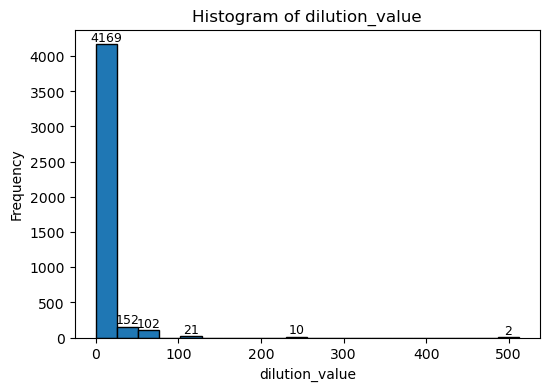

In [23]:
# Histogram
plt.figure(figsize=(6,4))
counts, bins, patches = plt.hist(df['dilution_value'].dropna(), bins=20, edgecolor='black')

plt.xlabel("dilution_value")
plt.ylabel("Frequency")
plt.title("Histogram of dilution_value")

# Annotate each bar with its frequency
for count, bin_left, patch in zip(counts, bins, patches):
    if count > 0:  # only label bars with non-zero height
        plt.text(bin_left + (patch.get_width()/2), count + 5,  # center on bar, slightly above
                 str(int(count)), ha='center', va='bottom', fontsize=9)

plt.show()

<p style="font-size:12px">

<b>Visualization of Skewed Numeric Data (dilution_value)</b><br>

The <code>dilution_value</code> column is highly skewed, with most values being small but a few extreme values much larger.  
Using a standard boxplot would stretch the scale due to these extremes, making the majority of the data difficult to interpret.

To address this, we apply a <b>symlog (symmetric log) scale</b> to the y-axis:  
<ul>
  <li>Compresses large values so that extreme points do not dominate the plot.</li>
  <li>Preserves small values, allowing us to see patterns in the bulk of the data.</li>
  <li>Provides a visually interpretable distribution without removing any data, respecting the clinical significance of extreme MIC dilution values.</li>
</ul>

<b>Interpretation of MIC dilution ranges:</b>
<ul>
  <li>0.06 → few cases → rare but valid</li>
  <li>0.12 → small but normal</li>
  <li>0.25–4 → common MIC range</li>
  <li>8–64 → moderately resistant</li>
  <li>128–512 → highly resistant strains (rare but expected)</li>
</ul>

This approach enables us to inspect unusual ranges and potential outliers before making any decisions about their handling.  

<b>Note:</b> For comparison, a normal boxplot is also plotted beside the symlog scale plot.

</p>

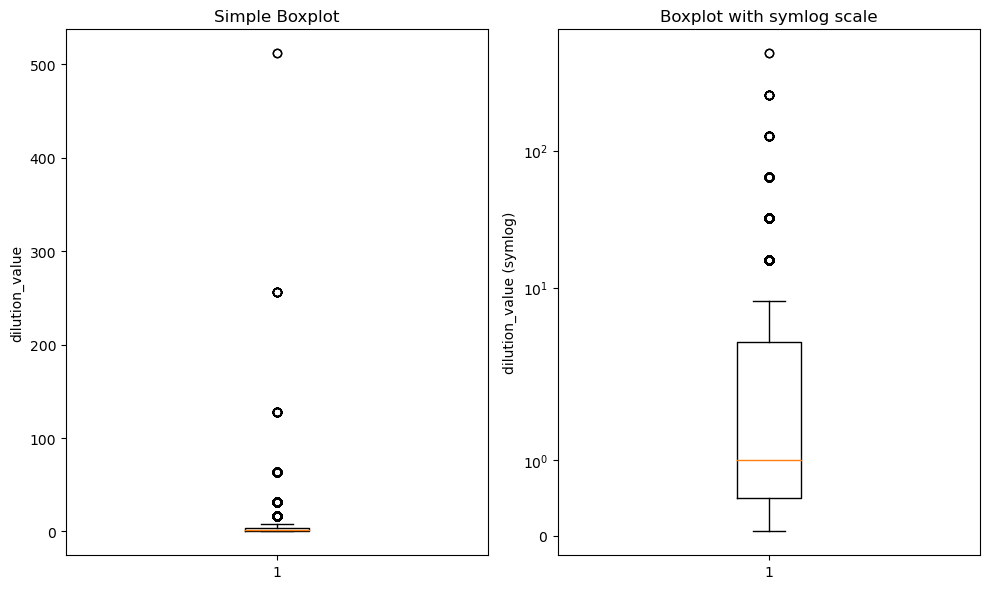

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10,6))  # 1 row, 2 columns

# Simple boxplot
axes[0].boxplot(df['dilution_value'].dropna())
axes[0].set_title("Simple Boxplot")
axes[0].set_ylabel("dilution_value")

# Boxplot with symlog scale
axes[1].boxplot(df['dilution_value'].dropna())
axes[1].set_yscale('symlog')
axes[1].set_title("Boxplot with symlog scale")
axes[1].set_ylabel("dilution_value (symlog)")

plt.tight_layout()
plt.show()

**Should we remove high `dilution_value` values?**

**Short Answer:** No — we shouldkeep all values, even the large ones.  
**Reason:** They are biologically valid MIC values, not errors.

**Why? (Clinical / MIC Context)**  
- `dilution_value` = Minimum Inhibitory Concentration (MIC) of an antibiotic.  
- MICs are measured in standard doubling steps: 0.06 → 0.12 → 0.25 → 0.5 → 1 → 2 → 4 → 8 → 16 → 32 → 64 → 128 → 256 → 512 …  
- Large values (128, 256, 512) indicate resistant strains, not mistakes.  

**Key Points:**  
- Rare high MIC → resistant strain ✅  
- Removing them → lose clinically important data ❌  
- Always preserve biological variability.

<p style="font-size:12px">

<b>Data Consistency Cleaning (String Fields)</b><br>

For all string-based categorical columns, consistency checks were performed to ensure that values are clean, standardized, and free from formatting discrepancies.  
Each column was evaluated based on the type of information it contains:

- <b>spec_type_desc</b> and <b>test_name</b>:  
  Checked for leading/trailing spaces, casing inconsistencies, duplicate variants, and unexpected spellings.

- <b>org_name</b> (organism) and <b>ab_name</b> (antibiotic):  
  Verified for inconsistent capitalization (e.g., “E.COLI” vs “E.coli”), extra characters, and spacing issues.

- <b>dilution_comparison</b>:  
  Validated against the standard comparison operators (<code>&lt;=</code>, <code>&gt;=</code>, <code>=</code>).  
  Any invalid symbols or typos were flagged for review.

- <b>interpretation</b>:  
  Confirmed expected microbiology categories (e.g., “S”, “I”, “R”).  
  Checked for lowercase versions, trailing spaces, or unexpected labels.

- <b>technician_id</b>:  
  Ensured uniform formatting (string type), removed accidental spaces or punctuation, and validated against the expected pattern (e.g., <code>TECH_063</code>).  
  Any entries not matching the regex <code>^TECH_\d{3}$</code> were flagged.

- <b>qc_flag</b>:  
  Validated expected values such as “QC_OK”, “QC_WARN”, “QC_FAIL”, depending on dataset documentation.

To support these checks, frequency tables, uniqueness checks, whitespace/format pattern checks, and regex validations were generated for each string column.  
This ensures that downstream analysis is not affected by subtle inconsistencies in categorical values.

</p>

In [25]:
# List of string columns
string_cols = [
    "spec_type_desc", "test_name", "org_name", "ab_name",
    "dilution_comparison", "interpretation",
    "technician_id", "qc_flag"
]

In [26]:
# ---- 1. Basic whitespace + casing cleanup preview ----
for col in string_cols:
    if col in df.columns:
        print(f"\n---- Column: {col} ----")
        print("Sample unique values BEFORE cleaning:")
        print(df[col].dropna().unique()[:10])  # show first 10


---- Column: spec_type_desc ----
Sample unique values BEFORE cleaning:
<StringArray>
[                             'MRSA SCREEN',
                                    'URINE',
                                   'SPUTUM',
                                    'STOOL',
                           'SEROLOGY/BLOOD',
                                     'SWAB',
                            'BLOOD CULTURE',
 'Rapid Respiratory Viral Screen & Culture',
  'FLUID RECEIVED IN BLOOD CULTURE BOTTLES',
                              'FLUID,OTHER']
Length: 10, dtype: string

---- Column: test_name ----
Sample unique values BEFORE cleaning:
<StringArray>
[                           'MRSA SCREEN',
            'Legionella Urinary Antigen ',
                             'GRAM STAIN',
                    'RESPIRATORY CULTURE',
                        'ACID FAST SMEAR',
                      'ACID FAST CULTURE',
 'CLOSTRIDIUM DIFFICILE TOXIN A & B TEST',
               'RAPID PLASMA REAGIN TEST',
  'R/O VANCOM

In [27]:
# ---- 2. Check for leading/trailing spaces ----
for col in string_cols:
    if col in df.columns:
        # Convert to string
        col_series = df[col].astype('string')
        
        # Find rows with leading/trailing spaces
        bad_spaces = df[col_series.str.contains(r"^\s+|\s+$", na=False)]
        
        # Count only non-NaN rows
        non_na_total = col_series.notna().sum()
        
        print(f"\n{col}: Rows with leading/trailing spaces = {len(bad_spaces)} / {non_na_total} (non-empty rows)")
        
        # Fix by stripping spaces
        df[col] = col_series.str.strip()


spec_type_desc: Rows with leading/trailing spaces = 0 / 14807 (non-empty rows)

test_name: Rows with leading/trailing spaces = 128 / 14807 (non-empty rows)

org_name: Rows with leading/trailing spaces = 1 / 5101 (non-empty rows)

ab_name: Rows with leading/trailing spaces = 0 / 4561 (non-empty rows)

dilution_comparison: Rows with leading/trailing spaces = 4456 / 4456 (non-empty rows)

interpretation: Rows with leading/trailing spaces = 0 / 4561 (non-empty rows)

technician_id: Rows with leading/trailing spaces = 0 / 14807 (non-empty rows)

qc_flag: Rows with leading/trailing spaces = 0 / 14807 (non-empty rows)


In [28]:
# ---- 3. Check for case inconsistencies ----
for col in ["spec_type_desc", "test_name", "org_name", "ab_name"]:
    if col in df.columns:
        col_series = df[col].astype('string')
        
        # Count only non-NaN rows
        non_na_total = col_series.notna().sum()
        # Check unique variants
        lower = col_series.dropna().str.islower().sum()
        upper = col_series.dropna().str.isupper().sum()
        print(f"\n{col}: unique lower-case variants = {lower}/{non_na_total}  | upper-case variants = {upper}/{non_na_total} (non-empty rows)")
        
        # Convert all to upper case
        df[col] = col_series.str.upper()


spec_type_desc: unique lower-case variants = 0/14807  | upper-case variants = 13724/14807 (non-empty rows)

test_name: unique lower-case variants = 0/14807  | upper-case variants = 10107/14807 (non-empty rows)

org_name: unique lower-case variants = 0/5101  | upper-case variants = 5101/5101 (non-empty rows)

ab_name: unique lower-case variants = 0/4561  | upper-case variants = 4561/4561 (non-empty rows)


In [29]:
# ---- 4. dilution_comparison: validate allowed symbols ----
valid_symbols = {"<=", "=>", "="}
invalid_comparison = df[
    (~df["dilution_comparison"].isin(valid_symbols)) & 
    df["dilution_comparison"].notna()
]
print(f"\nInvalid dilution_comparison entries: {len(invalid_comparison)}")
if len(invalid_comparison) > 0:
    display(invalid_comparison.head())


Invalid dilution_comparison entries: 0


In [30]:
# ---- 5. interpretation: check expected microbiology labels ----
expected_interpretations = {"S", "I", "R"}
unexpected_interp = df[
    (~df["interpretation"].isin(expected_interpretations)) & 
    df["interpretation"].notna()
]
print(f"\nUnexpected interpretation labels: {len(unexpected_interp)}")
if len(unexpected_interp) > 0:
    display(unexpected_interp.head())


Unexpected interpretation labels: 0


In [31]:
# ---- 6. qc_flag: check unique values ----
expected_qc_flag = {'QC_OK', 'QC_WARN', 'QC_FAIL'}
unexpected_qc_flag = df[
    (~df["qc_flag"].isin(expected_qc_flag)) & 
    df["qc_flag"].notna()
]
print(f"\nUnexpected quality check flag labels: {len(unexpected_qc_flag)}")
if len(unexpected_qc_flag) > 0:
    display(unexpected_qc_flag.head())


Unexpected quality check flag labels: 0


In [32]:
# ---- 7. technician_id: regex pattern validation ----
pattern = r"^TECH_\d+$"

invalid_technician_ids = df[
    ~df["technician_id"].astype(str).str.match(pattern) & 
    df["technician_id"].notna()
]

print(f"\nTechnician IDs not matching expected pattern 'TECH_###': {len(invalid_technician_ids)}")
if len(invalid_technician_ids) > 0:
    display(invalid_technician_ids.head())


Technician IDs not matching expected pattern 'TECH_###': 0


##### Creating a dataframe for our cleaned dataset.

In [33]:
df_cleaned = df.copy()

# Patient + Dataset level Analysis

### Mapping few named columns to a general classifiable set of fields

In [34]:
# spec_type_desc -> anatomical_site, sterile_site, collection_invasiveness, sample_format
SPEC_TYPE_MAP = {'MRSA SCREEN': {
    'anatomical_site': 'Nares (screen)', 
    'sterile_site': 0, 
    'collection_invasiveness': 'Non-invasive', 
    'sample_format': 'Swab'},
 'URINE': {'anatomical_site': 'Urinary tract', 'sterile_site': 0, 'collection_invasiveness': 'Non-invasive', 'sample_format': 'Fluid'},
 'SPUTUM': {'anatomical_site': 'Respiratory tract', 'sterile_site': 0, 'collection_invasiveness': 'Non-invasive', 'sample_format': 'Fluid'},
 'STOOL': {'anatomical_site': 'Gastrointestinal tract', 'sterile_site': 0, 'collection_invasiveness': 'Non-invasive', 'sample_format': 'Fluid'},
 'SEROLOGY/BLOOD': {'anatomical_site': 'Blood (serology)', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Fluid'},
 'SWAB': {'anatomical_site': 'Not specified', 'sterile_site': 0, 'collection_invasiveness': 'Non-invasive', 'sample_format': 'Swab'},
 'BLOOD CULTURE': {'anatomical_site': 'Bloodstream', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Fluid'},
 'RAPID RESPIRATORY VIRAL SCREEN & CULTURE': {'anatomical_site': 'Respiratory tract', 'sterile_site': 0, 'collection_invasiveness': 'Non-invasive', 'sample_format': 'Swab'},
 'FLUID RECEIVED IN BLOOD CULTURE BOTTLES': {'anatomical_site': 'Bloodstream', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Fluid'},
 'FLUID,OTHER': {'anatomical_site': 'Other fluid (unspecified)', 'sterile_site': 'Not specified', 'collection_invasiveness': 'Not specified', 'sample_format': 'Fluid'},
 'STAPH AUREUS SWAB': {'anatomical_site': 'Skin / mucosa', 'sterile_site': 0, 'collection_invasiveness': 'Non-invasive', 'sample_format': 'Swab'},
 'THROAT FOR STREP': {'anatomical_site': 'Throat / oropharynx', 'sterile_site': 0, 'collection_invasiveness': 'Non-invasive', 'sample_format': 'Swab'},
 'PLEURAL FLUID': {'anatomical_site': 'Pleural cavity', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Fluid'},
 'BLOOD (CMV AB)': {'anatomical_site': 'Blood (serology)', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Fluid'},
 'INFLUENZA A/B BY DFA': {'anatomical_site': 'Respiratory tract', 'sterile_site': 0, 'collection_invasiveness': 'Non-invasive', 'sample_format': 'Swab'},
 'PERITONEAL FLUID': {'anatomical_site': 'Peritoneal cavity', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Fluid'},
 'TISSUE': {'anatomical_site': 'Tissue (biopsy)', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Tissue'},
 'IMMUNOLOGY': {'anatomical_site': 'Blood (immunology/serology)', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Fluid'},
 'ASPIRATE': {'anatomical_site': 'Not specified (aspirate)', 'sterile_site': 'Not specified', 'collection_invasiveness': 'Invasive', 'sample_format': 'Aspirate'},
 'BLOOD CULTURE ( MYCO/F LYTIC BOTTLE)': {'anatomical_site': 'Bloodstream', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Fluid'},
 'BRONCHOALVEOLAR LAVAGE': {'anatomical_site': 'Respiratory tract (lower)', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Fluid'},
 'CSF;SPINAL FLUID': {'anatomical_site': 'Central nervous system (CSF)', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Fluid'},
 'BLOOD (EBV)': {'anatomical_site': 'Blood (serology)', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Fluid'},
 'BLOOD (TOXO)': {'anatomical_site': 'Blood (serology)', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Fluid'},
 'CATHETER TIP-IV': {'anatomical_site': 'Device-related (catheter tip)', 'sterile_site': 1, 'collection_invasiveness': 'Invasive (device)', 'sample_format': 'Device'},
 'CRE SCREEN': {'anatomical_site': 'Rectal swab (screen)', 'sterile_site': 0, 'collection_invasiveness': 'Non-invasive', 'sample_format': 'Swab'},
 'BRONCHIAL WASHINGS': {'anatomical_site': 'Respiratory tract (lower)', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Fluid'},
 'BLOOD (LYME)': {'anatomical_site': 'Blood (serology)', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Fluid'},
 'JOINT FLUID': {'anatomical_site': 'Joint space', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Fluid'},
 'DIRECT ANTIGEN TEST FOR VARICELLA-ZOSTER VIRUS': {'anatomical_site': 'Skin / lesion (likely)', 'sterile_site': 0, 'collection_invasiveness': 'Non-invasive', 'sample_format': 'Swab'},
 'DIRECT ANTIGEN TEST FOR HERPES SIMPLEX VIRUS TYPES 1 & 2': {'anatomical_site': 'Skin / lesion / mucosa', 'sterile_site': 0, 'collection_invasiveness': 'Non-invasive', 'sample_format': 'Swab'},
 'IMMUNOLOGY (CMV)': {'anatomical_site': 'Blood (immunology/serology)', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Fluid'},
 'MINI-BAL': {'anatomical_site': 'Respiratory tract (lower)', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Fluid'},
 'STOOL (RECEIVED IN TRANSPORT SYSTEM)': {'anatomical_site': 'Gastrointestinal tract', 'sterile_site': 0, 'collection_invasiveness': 'Non-invasive', 'sample_format': 'Fluid'},
 'THROAT CULTURE': {'anatomical_site': 'Throat / oropharynx', 'sterile_site': 0, 'collection_invasiveness': 'Non-invasive', 'sample_format': 'Swab'},
 'BILE': {'anatomical_site': 'Biliary tract', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Fluid'},
 'DIALYSIS FLUID': {'anatomical_site': 'Dialysis fluid', 'sterile_site': 1, 'collection_invasiveness': 'Invasive (procedure-related)', 'sample_format': 'Fluid'},
 'BRONCHIAL BRUSH': {'anatomical_site': 'Respiratory tract (lower)', 'sterile_site': 1, 'collection_invasiveness': 'Invasive', 'sample_format': 'Brush'},
 'SKIN SCRAPINGS': {'anatomical_site': 'Skin', 'sterile_site': 0, 'collection_invasiveness': 'Non-invasive', 'sample_format': 'Tissue (scraping)'},
 'ABSCESS': {'anatomical_site': 'Skin / soft tissue (abscess)', 'sterile_site': 0, 'collection_invasiveness': 'Invasive (drainage)', 'sample_format': 'Fluid/Tissue'},
 'FOREIGN BODY': {'anatomical_site': 'Device/foreign body', 'sterile_site': 1, 'collection_invasiveness': 'Invasive (device)', 'sample_format': 'Device'},
 'EAR': {'anatomical_site': 'Ear', 'sterile_site': 'Not specified', 'collection_invasiveness': 'Not specified', 'sample_format': 'Swab/Specimen'}}
# test_name -> test_modality, target_organism_class, purpose_specific
TEST_NAME_MAP = {'MRSA SCREEN': {
    'test_modality': 'Screening assay (molecular/culture)', 
    'target_organism_class': 'Bacteria', 
    'purpose_specific': ['Screening']},
 'LEGIONELLA URINARY ANTIGEN': {'test_modality': 'Antigen detection', 'target_organism_class': 'Bacteria', 'purpose_specific': ['Diagnostic']},
 'GRAM STAIN': {'test_modality': 'Microscopy', 'target_organism_class': 'Bacteria (visual)', 'purpose_specific': ['Diagnostic']},
 'RESPIRATORY CULTURE': {'test_modality': 'Culture', 'target_organism_class': 'Bacteria/Fungus (dependent)', 'purpose_specific': ['Diagnostic']},
 'ACID FAST SMEAR': {'test_modality': 'Microscopy (AFB)', 'target_organism_class': 'Mycobacteria/acid-fast organisms', 'purpose_specific': ['Diagnostic']},
 'ACID FAST CULTURE': {'test_modality': 'Culture (AFB)', 'target_organism_class': 'Mycobacteria', 'purpose_specific': ['Diagnostic']},
 'CLOSTRIDIUM DIFFICILE TOXIN A & B TEST': {'test_modality': 'Antigen/toxin detection', 'target_organism_class': 'Bacteria (Clostridioides difficile)', 'purpose_specific': ['Diagnostic']},
 'RAPID PLASMA REAGIN TEST': {'test_modality': 'Serology', 'target_organism_class': 'Serology (non-treponemal)', 'purpose_specific': ['Screening', 'Diagnostic']},
 'R/O VANCOMYCIN RESISTANT ENTEROCOCCUS': {'test_modality': 'Screening / rule-out assay', 'target_organism_class': 'Bacteria', 'purpose_specific': ['Resistance surveillance', 'Screening']},
 'URINE CULTURE': {'test_modality': 'Culture', 'target_organism_class': 'Bacteria', 'purpose_specific': ['Diagnostic']},
 'BLOOD CULTURE, ROUTINE': {'test_modality': 'Culture (blood)', 'target_organism_class': 'Bacteria/Fungus', 'purpose_specific': ['Diagnostic']},
 'RESPIRATORY VIRAL CULTURE': {'test_modality': 'Culture (viral)', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'RESPIRATORY VIRAL ANTIGEN SCREEN': {'test_modality': 'Antigen detection', 'target_organism_class': 'Virus', 'purpose_specific': ['Screening', 'Diagnostic']},
 'FLUID CULTURE IN BOTTLES': {'test_modality': 'Culture', 'target_organism_class': 'Bacteria/Fungus', 'purpose_specific': ['Diagnostic']},
 'FLUID CULTURE': {'test_modality': 'Culture', 'target_organism_class': 'Bacteria/Fungus', 'purpose_specific': ['Diagnostic']},
 'ANAEROBIC CULTURE': {'test_modality': 'Culture (anaerobic)', 'target_organism_class': 'Bacteria (anaerobes)', 'purpose_specific': ['Diagnostic']},
 'FUNGAL CULTURE': {'test_modality': 'Culture', 'target_organism_class': 'Fungus', 'purpose_specific': ['Diagnostic']},
 'FECAL CULTURE': {'test_modality': 'Culture', 'target_organism_class': 'Bacteria/Parasite (dependent)', 'purpose_specific': ['Diagnostic']},
 'CAMPYLOBACTER CULTURE': {'test_modality': 'Culture', 'target_organism_class': 'Bacteria', 'purpose_specific': ['Diagnostic']},
 'C. DIFFICILE PCR': {'test_modality': 'Molecular amplification', 'target_organism_class': 'Bacteria (Clostridioides difficile)', 'purpose_specific': ['Diagnostic']},
 'STAPH AUREUS SCREEN': {'test_modality': 'Screening assay', 'target_organism_class': 'Bacteria', 'purpose_specific': ['Screening']},
 'R/O BETA STREP GROUP A': {'test_modality': 'Screening/Rule-out', 'target_organism_class': 'Bacteria', 'purpose_specific': ['Screening', 'Diagnostic']},
 'LYME SEROLOGY': {'test_modality': 'Serology', 'target_organism_class': 'Bacteria (Borrelia)', 'purpose_specific': ['Diagnostic']},
 'CMV IGG ANTIBODY': {'test_modality': 'Serology', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'CMV IGM ANTIBODY': {'test_modality': 'Serology', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'DIRECT INFLUENZA A ANTIGEN TEST': {'test_modality': 'Antigen detection', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'DIRECT INFLUENZA B ANTIGEN TEST': {'test_modality': 'Antigen detection', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'AEROBIC BOTTLE GRAM STAIN': {'test_modality': 'Microscopy', 'target_organism_class': 'Bacteria (visual)', 'purpose_specific': ['Diagnostic']},
 'WOUND CULTURE': {'test_modality': 'Culture', 'target_organism_class': 'Bacteria/Fungus', 'purpose_specific': ['Diagnostic']},
 'TISSUE': {'test_modality': 'Culture / pathology', 'target_organism_class': 'Bacteria/Fungus', 'purpose_specific': ['Diagnostic']},
 'HIV-1 VIRAL LOAD/ULTRASENSITIVE': {'test_modality': 'Molecular (quantitative)', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'VIRAL CULTURE': {'test_modality': 'Culture (viral)', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'ANAEROBIC BOTTLE GRAM STAIN': {'test_modality': 'Microscopy', 'target_organism_class': 'Bacteria (anaerobes)', 'purpose_specific': ['Diagnostic']},
 'BLOOD/FUNGAL CULTURE': {'test_modality': 'Culture', 'target_organism_class': 'Fungus/Bacteria', 'purpose_specific': ['Diagnostic']},
 'BLOOD/AFB CULTURE': {'test_modality': 'Culture (AFB)', 'target_organism_class': 'Mycobacteria', 'purpose_specific': ['Diagnostic']},
 'LEGIONELLA CULTURE': {'test_modality': 'Culture', 'target_organism_class': 'Bacteria', 'purpose_specific': ['Diagnostic']},
 'VARICELLA-ZOSTER IGG SEROLOGY': {'test_modality': 'Serology', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'EPSTEIN-BARR VIRUS VCA-IGG AB': {'test_modality': 'Serology', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'EPSTEIN-BARR VIRUS EBNA IGG AB': {'test_modality': 'Serology', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'EPSTEIN-BARR VIRUS VCA-IGM AB': {'test_modality': 'Serology', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'TOXOPLASMA IGG ANTIBODY': {'test_modality': 'Serology', 'target_organism_class': 'Parasite', 'purpose_specific': ['Diagnostic']},
 'OVA + PARASITES': {'test_modality': 'Microscopy / O&P', 'target_organism_class': 'Parasite', 'purpose_specific': ['Diagnostic']},
 'CRYPTOSPORIDIUM/GIARDIA (DFA)': {'test_modality': 'Antigen / DFA', 'target_organism_class': 'Parasite', 'purpose_specific': ['Diagnostic']},
 'STAPH AUREUS PREOP PCR': {'test_modality': 'Molecular (PCR)', 'target_organism_class': 'Bacteria', 'purpose_specific': ['Screening']},
 'RPR W/CHECK FOR PROZONE': {'test_modality': 'Serology', 'target_organism_class': 'Serology (non-treponemal)', 'purpose_specific': ['Screening', 'Diagnostic']},
 'CARBAPENEMASE RESISTANT ENTEROBACTERIACEAE SCREEN': {'test_modality': 'Screening (phenotypic/molecular)', 'target_organism_class': 'Bacteria', 'purpose_specific': ['Resistance surveillance', 'Screening']},
 'TOXOPLASMA IGM ANTIBODY': {'test_modality': 'Serology', 'target_organism_class': 'Parasite', 'purpose_specific': ['Diagnostic']},
 'ASO SCREEN': {'test_modality': 'Serology', 'target_organism_class': 'Bacteria (streptococcal antibodies)', 'purpose_specific': ['Screening', 'Diagnostic']},
 'LYME IGG': {'test_modality': 'Serology', 'target_organism_class': 'Bacteria', 'purpose_specific': ['Diagnostic']},
 'CHLAMYDIA TRACHOMATIS, NUCLEIC ACID PROBE, WITH AMPLIFICATION': {'test_modality': 'Molecular', 'target_organism_class': 'Bacteria', 'purpose_specific': ['Diagnostic']},
 'NEISSERIA GONORRHOEAE (GC), NUCLEIC ACID PROBE, WITH AMPLIFICATION': {'test_modality': 'Molecular', 'target_organism_class': 'Bacteria', 'purpose_specific': ['Diagnostic']},
 'DIRECT ANTIGEN TEST FOR VARICELLA-ZOSTER VIRUS': {'test_modality': 'Antigen detection', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'DIRECT ANTIGEN TEST FOR HERPES SIMPLEX VIRUS TYPES 1 & 2': {'test_modality': 'Antigen detection', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'POTASSIUM HYDROXIDE PREPARATION': {'test_modality': 'Microscopy (KOH)', 'target_organism_class': 'Fungus', 'purpose_specific': ['Diagnostic']},
 'CLOSTRIDIUM DIFFICILE TOXIN ASSAY': {'test_modality': 'Antigen/toxin detection', 'target_organism_class': 'Bacteria (Clostridioides difficile)', 'purpose_specific': ['Diagnostic']},
 'IMMUNOFLUORESCENT TEST FOR PNEUMOCYSTIS JIROVECII (CARINII)': {'test_modality': 'Immunofluorescence microscopy', 'target_organism_class': 'Fungus (Pneumocystis jirovecii)', 'purpose_specific': ['Diagnostic']},
 'CMV VIRAL LOAD': {'test_modality': 'Molecular (quantitative)', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'YEAST VAGINITIS CULTURE': {'test_modality': 'Culture', 'target_organism_class': 'Fungus', 'purpose_specific': ['Diagnostic']},
 'MTB DIRECT AMPLIFICATION': {'test_modality': 'Molecular', 'target_organism_class': 'Mycobacteria', 'purpose_specific': ['Diagnostic']},
 'BRUCELLA BLOOD CULTURE': {'test_modality': 'Culture', 'target_organism_class': 'Bacteria', 'purpose_specific': ['Diagnostic']},
 'HBV VIRAL LOAD': {'test_modality': 'Molecular (quantitative)', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'HCV VIRAL LOAD': {'test_modality': 'Molecular (quantitative)', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'FECAL CULTURE - R/O VIBRIO': {'test_modality': 'Culture (targeted)', 'target_organism_class': 'Bacteria', 'purpose_specific': ['Diagnostic']},
 'FECAL CULTURE - R/O YERSINIA': {'test_modality': 'Culture (targeted)', 'target_organism_class': 'Bacteria', 'purpose_specific': ['Diagnostic']},
 'FECAL CULTURE - R/O E.COLI 0157:H7': {'test_modality': 'Culture (targeted)', 'target_organism_class': 'Bacteria', 'purpose_specific': ['Diagnostic']},
 'MICROSPORIDIA STAIN': {'test_modality': 'Microscopy / stain', 'target_organism_class': 'Microsporidia (parasite)', 'purpose_specific': ['Diagnostic']},
 'CYCLOSPORA STAIN': {'test_modality': 'Microscopy / stain', 'target_organism_class': 'Parasite', 'purpose_specific': ['Diagnostic']},
 'HELICOBACTER PYLORI ANTIBODY TEST': {'test_modality': 'Serology', 'target_organism_class': 'Bacteria', 'purpose_specific': ['Diagnostic']},
 'LYME IGM': {'test_modality': 'Serology', 'target_organism_class': 'Bacteria', 'purpose_specific': ['Diagnostic']},
 'MUMPS IGG ANTIBODY': {'test_modality': 'Serology', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'MONOSPOT': {'test_modality': 'Serology (heterophile)', 'target_organism_class': 'Heterophile antibody (non-specific)', 'purpose_specific': ['Diagnostic']},
 'VIRAL CULTURE: R/O HERPES SIMPLEX VIRUS': {'test_modality': 'Viral culture', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'RUBELLA IGG SEROLOGY': {'test_modality': 'Serology', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'RUBEOLA ANTIBODY, IGG': {'test_modality': 'Serology', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'CRYPTOCOCCAL ANTIGEN': {'test_modality': 'Antigen detection', 'target_organism_class': 'Fungus', 'purpose_specific': ['Diagnostic']},
 'VARICELLA-ZOSTER CULTURE': {'test_modality': 'Viral culture', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'RESPIRATORY VIRUS IDENTIFICATION': {'test_modality': 'Multiplex identification', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'QUANTITATIVE RPR': {'test_modality': 'Serology', 'target_organism_class': 'Serology (non-treponemal)', 'purpose_specific': ['Diagnostic']},
 'TREPONEMAL ANTIBODY TEST': {'test_modality': 'Serology (treponemal)', 'target_organism_class': 'Bacteria (Treponema pallidum)', 'purpose_specific': ['Diagnostic']},
 'ENTEROVIRUS CULTURE': {'test_modality': 'Viral culture', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'NOCARDIA CULTURE': {'test_modality': 'Culture', 'target_organism_class': 'Bacteria (Nocardia)', 'purpose_specific': ['Diagnostic']},
 'VIRAL CULTURE: R/O CYTOMEGALOVIRUS': {'test_modality': 'Viral culture', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'CYTOMEGALOVIRUS EARLY ANTIGEN TEST (SHELL VIAL METHOD)': {'test_modality': 'Antigen/culture adjunct', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'FUNGAL CULTURE (HAIR/SKIN/NAILS)': {'test_modality': 'Culture', 'target_organism_class': 'Fungus', 'purpose_specific': ['Diagnostic']},
 'POTASSIUM HYDROXIDE PREPARATION (HAIR/SKIN/NAILS)': {'test_modality': 'Microscopy (KOH)', 'target_organism_class': 'Fungus', 'purpose_specific': ['Diagnostic']},
 'MYCO-F BOTTLE GRAM STAIN': {'test_modality': 'Microscopy (AFB workflow)', 'target_organism_class': 'Mycobacteria', 'purpose_specific': ['Diagnostic']},
 'HCV GENOTYPE': {'test_modality': 'Molecular (genotyping)', 'target_organism_class': 'Virus', 'purpose_specific': ['Diagnostic']},
 'GENITAL CULTURE': {'test_modality': 'Culture', 'target_organism_class': 'Bacteria/Fungus', 'purpose_specific': ['Diagnostic']},
 'O&P MACROSCOPIC EXAM - WORM': {'test_modality': 'Macroscopic exam', 'target_organism_class': 'Parasite', 'purpose_specific': ['Diagnostic']},
 'GRAM STAIN- R/O THRUSH': {'test_modality': 'Microscopy (Gram stain)', 'target_organism_class': 'Fungus/Bacteria (Candida vs bacteria)', 'purpose_specific': ['Diagnostic']}}
df_cleaned[["org_name"]] = df_cleaned[["org_name"]].fillna("")
# org_name -> biological_kingdom, non_specific_organism
ORG_NAME_MAP = {
    '': {"biological_kingdom": "Not an organism / Missing", "non_specific_organism": 1},
    "POSITIVE FOR METHICILLIN RESISTANT STAPH AUREUS": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "YEAST": {"biological_kingdom": "Fungus", "non_specific_organism": 1},
    "KLEBSIELLA OXYTOCA": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "GRAM POSITIVE BACTERIA": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "ENTEROBACTER CLOACAE COMPLEX": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "GRAM NEGATIVE ROD(S)": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "ESCHERICHIA COLI": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "STAPH AUREUS COAG +": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "BETA STREPTOCOCCUS GROUP B": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "ACHROMOBACTER SPECIES": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "CANCELLED": {"biological_kingdom": "Not an organism / Cancelled", "non_specific_organism": 1},
    "STAPHYLOCOCCUS, COAGULASE NEGATIVE": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "CORYNEBACTERIUM SPECIES (DIPHTHEROIDS)": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "ENTEROCOCCUS SP.": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "NEISSERIA MENINGITIDIS": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "CITROBACTER KOSERI": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "SERRATIA MARCESCENS": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "CORYNEBACTERIUM UREALYTICUM SP. NOV.": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "ASPERGILLUS SPECIES": {"biological_kingdom": "Fungus", "non_specific_organism": 1},
    "PROTEUS MIRABILIS": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "KLEBSIELLA PNEUMONIAE": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "CLOSTRIDIUM DIFFICILE": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "STREPTOCOCCUS PNEUMONIAE": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "S. AUREUS POSITIVE; MRSA NEGATIVE": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "PSEUDOMONAS AERUGINOSA": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "CITROBACTER FREUNDII COMPLEX": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "ENTEROBACTER CLOACAE": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "POSITIVE FOR PNEUMOCYSTIS JIROVECII (CARINII)": {"biological_kingdom": "Fungus", "non_specific_organism": 0},
    "ENTEROCOCCUS FAECIUM": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "MOLD": {"biological_kingdom": "Fungus", "non_specific_organism": 1},
    "GRAM NEGATIVE ROD #2": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "PRESUMPTIVE PROPIONIBACTERIUM ACNES": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "ENTEROBACTER ASBURIAE": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "STAPHYLOCOCCUS EPIDERMIDIS": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "HAEMOPHILUS SPECIES NOT INFLUENZAE": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "ENTEROBACTER AEROGENES": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "PROBABLE ENTEROCOCCUS": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "MIXED BACTERIAL FLORA": {"biological_kingdom": "Bacteria (mixed)", "non_specific_organism": 1},
    "CLOSTRIDIUM SPECIES NOT C. PERFRINGENS OR C. SEPTICUM": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "PROPIONIBACTERIUM ACNES": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "ANAEROBIC GRAM POSITIVE COCCUS(I)": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "VIRIDANS STREPTOCOCCI": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "STAPHYLOCOCCUS HOMINIS": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "MYCOBACTERIUM AVIUM COMPLEX": {"biological_kingdom": "Mycobacteria", "non_specific_organism": 0},
    "ASPERGILLUS FUMIGATUS": {"biological_kingdom": "Fungus", "non_specific_organism": 0},
    "PSEUDOMONAS SPECIES": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "PROTEUS VULGARIS GROUP": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "GRAM NEGATIVE ROD #3": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "STENOTROPHOMONAS MALTOPHILIA": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "GRAM POSITIVE COCCUS(COCCI)": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "PROVIDENCIA RETTGERI": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "POSITIVE FOR INFLUENZA A VIRAL ANTIGEN": {"biological_kingdom": "Virus", "non_specific_organism": 1},
    "STREPTOCOCCUS GALLOLYTICUS SSP. PASTEURIANUS (STREPTOCOCCUS BOVIS)": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "ENTEROCOCCUS FAECALIS": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "HAEMOPHILUS INFLUENZAE, BETA-LACTAMASE POSITIVE": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "MORAXELLA CATARRHALIS": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "NON-FERMENTER, NOT PSEUDOMONAS AERUGINOSA": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "ENTEROCOCCUS RAFFINOSUS": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "TRICHOPHYTON SPECIES": {"biological_kingdom": "Fungus", "non_specific_organism": 0},
    "PRESUMPTIVE GARDNERELLA VAGINALIS": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "STREPTOCOCCUS ANGINOSUS (MILLERI) GROUP": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "CYTOMEGALOVIRUS": {"biological_kingdom": "Virus", "non_specific_organism": 0},
    "MORGANELLA MORGANII": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "HAEMOPHILUS INFLUENZAE, BETA-LACTAMASE NEGATIVE": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "GRAM POSITIVE RODS": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "PROPIONIBACTERIUM SPECIES": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "GRAM NEGATIVE ROD #4": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "ENTEROBACTER SPECIES": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "CANDIDA ALBICANS, PRESUMPTIVE IDENTIFICATION": {"biological_kingdom": "Fungus", "non_specific_organism": 0},
    "GIARDIA CYSTS": {"biological_kingdom": "Parasite", "non_specific_organism": 0},
    "MYCOBACTERIUM FORTUITUM": {"biological_kingdom": "Mycobacteria", "non_specific_organism": 0},
    "GEMELLA SPECIES": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "PENICILLIUM SPECIES": {"biological_kingdom": "Fungus", "non_specific_organism": 0},
    "HERPES SIMPLEX VIRUS TYPE 1": {"biological_kingdom": "Virus", "non_specific_organism": 0},
    "ASPERGILLUS SP. NOT FUMIGATUS, FLAVUS OR NIGER": {"biological_kingdom": "Fungus", "non_specific_organism": 1},
    "BETA STREPTOCOCCUS GROUP A": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "LACTOBACILLUS SPECIES": {"biological_kingdom": "Bacteria", "non_specific_organism": 0},
    "CANDIDA TROPICALIS": {"biological_kingdom": "Fungus", "non_specific_organism": 0},
    "ENTEROBACTERIACEAE": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "STAPHYLOCOCCUS SPECIES": {"biological_kingdom": "Bacteria", "non_specific_organism": 1},
    "STAPHYLOCOCCUS LUGDUNENSIS": {"biological_kingdom": "Bacteria", "non_specific_organism": 0}
}
def apply_microbiology_mappings(df_cleaned):
    """
    Input: df with columns 'spec_type_desc', 'test_name', 'org_name'
    Output: df with appended deterministic feature columns:
      anatomical_site, sterile_site, collection_invasiveness, sample_format,
      test_modality, target_organism_class, purpose_specific,
      biological_kingdom, non_specific_organism
    """
    # create output columns with defaults
    out = df_cleaned.copy()

    out["anatomical_site"] = None
    out["sterile_site"] = "Not specified"
    out["collection_invasiveness"] = "Not specified"
    out["sample_format"] = "Not specified"

    out["test_modality"] = None
    out["target_organism_class"] = None
    out["purpose_specific"] = None

    out["biological_kingdom"] = None
    out["non_specific_organism"] = 1  # default to conservative: non-specific unless mapped

    # apply spec_type_desc mapping
    for k, v in SPEC_TYPE_MAP.items():
        mask = out["spec_type_desc"].astype(str).str.strip() == k
        if mask.any():
            out.loc[mask, "anatomical_site"] = v["anatomical_site"]
            out.loc[mask, "sterile_site"] = v["sterile_site"]
            out.loc[mask, "collection_invasiveness"] = v["collection_invasiveness"]
            out.loc[mask, "sample_format"] = v["sample_format"]

    # apply test_name mapping
    for k, v in TEST_NAME_MAP.items():
        mask = out["test_name"].astype(str).str.strip() == k
        if mask.any():
            out.loc[mask, "test_modality"] = v["test_modality"]
            out.loc[mask, "target_organism_class"] = v["target_organism_class"]
            out.loc[mask, "purpose_specific"] = ",".join(v["purpose_specific"]) if isinstance(v["purpose_specific"], list) else v["purpose_specific"]

    # apply org_name mapping
    # match None as missing as well
    for k, v in ORG_NAME_MAP.items():
        if k is None:
            mask = out["org_name"].isna()
        else:
            mask = out["org_name"].astype(str).str.strip() == k
        if mask.any():
            out.loc[mask, "biological_kingdom"] = v["biological_kingdom"]
            out.loc[mask, "non_specific_organism"] = v["non_specific_organism"]

    # return augmented dataframe
    return out

In [35]:
mapped_df = apply_microbiology_mappings(df_cleaned)

In [36]:
cols = ['anatomical_site',
       'sterile_site', 'collection_invasiveness', 'sample_format',
       'test_modality', 'target_organism_class', 'purpose_specific',
       'biological_kingdom', 'non_specific_organism']

In [37]:
df_cleaned[cols] = mapped_df[cols]

# Patient-level Analysis

In [66]:
import pandas as pd
from collections import defaultdict
from datetime import datetime

def build_patient_profiles(df_cleaned):
    df = df_cleaned.copy()
    # stable record id
    df["__record_id"] = df.index.tolist()  # zero-based index

    # Create boolean for antibiotic test row (ab_name present)
    df["__has_ab_test"] = df["ab_name"].notna() & (df["ab_name"].str.strip() != "")

    # We'll compute RSI only on QC_OK rows (and include QC_WARN per your update)
    df["__qc_ok"] = df["qc_flag"].isin({"QC_OK", "QC_WARN"})

    # Make sure charttime is datetime (if already cleaned this is safe)
    if "charttime" in df.columns:
        df["charttime"] = pd.to_datetime(df["charttime"], errors="coerce", dayfirst=True)

    profiles = {
        "created_at": datetime.utcnow().isoformat() + "Z",
        "subjects": {}
    }

    extra_cols = [
        "anatomical_site", "sterile_site", "collection_invasiveness", "sample_format",
        "test_modality", "target_organism_class", "purpose_specific",
        "biological_kingdom", "non_specific_organism"
    ]
    # ensure these columns exist in df to avoid KeyError
    for c in extra_cols:
        if c not in df.columns:
            df[c] = None

    for subject, srows in df.groupby("subject_id", sort=False):
        subject_key = str(subject)

        # Basic aggregated metrics across all hadm_ids for this subject
        total_records = len(srows)
        unique_spec_types = srows["spec_type_desc"].dropna().map(lambda x: str(x).strip()).unique().tolist()
        unique_tests = srows["test_name"].dropna().map(lambda x: str(x).strip()).unique().tolist()
        unique_orgs = srows["org_name"].dropna().map(lambda x: str(x).strip()).unique().tolist()
        unique_abs = srows["ab_name"].dropna().map(lambda x: str(x).strip()).unique().tolist()
        num_ab_tests = int(srows["__has_ab_test"].sum())

        # extra combined fields at subject level
        subj_extras = {}
        for c in extra_cols:
            subj_extras[c] = srows[c].dropna().map(lambda x: str(x).strip()).unique().tolist()

        # first_test / last_test across subject (charttime)
        if srows["charttime"].notna().any():
            first_dt = pd.to_datetime(srows["charttime"].min())
            last_dt  = pd.to_datetime(srows["charttime"].max())
            first_test = first_dt.isoformat()
            last_test = last_dt.isoformat()
            days_between_tests = int((last_dt - first_dt).days)
        else:
            first_test = None
            last_test = None
            days_between_tests = None

        # RSI counts and ratios: only on QC_OK rows and rows that are already 'R','S','I'
        qc_ok_rows = srows[srows["__qc_ok"]]
        # assume interpretation column already normalized to 'R','S','I' per your note
        r_count = int((qc_ok_rows["interpretation"] == "R").sum())
        s_count = int((qc_ok_rows["interpretation"] == "S").sum())
        i_count = int((qc_ok_rows["interpretation"] == "I").sum())
        total_rsi = r_count + s_count + i_count
        rsi_ratios = {
            "R": None, "S": None, "I": None,
            "S_over_total_rsi": None, "S_&_I_over_total_rsi": None
        }
        if total_rsi > 0:
            rsi_ratios["R"] = r_count
            rsi_ratios["S"] = s_count
            rsi_ratios["I"] = i_count
            rsi_ratios["S_over_total_rsi"] = s_count / total_rsi
            rsi_ratios["S_&_I_over_total_rsi"] = (s_count + i_count) / total_rsi

        # Build hadm-level details
        hadm_dict = {}
        for hadm, hrows in srows.groupby("hadm_id", sort=False):
            hadm_key = str(hadm)
            record_ids = hrows["__record_id"].tolist()

            # hadm-level metrics (same as subject but scoped)
            h_total_records = len(hrows)
            h_unique_spec_types = hrows["spec_type_desc"].dropna().map(lambda x: str(x).strip()).unique().tolist()
            h_unique_tests = hrows["test_name"].dropna().map(lambda x: str(x).strip()).unique().tolist()
            h_unique_orgs = hrows["org_name"].dropna().map(lambda x: str(x).strip()).unique().tolist()
            h_unique_abs = hrows["ab_name"].dropna().map(lambda x: str(x).strip()).unique().tolist()
            h_num_ab_tests = int(hrows["__has_ab_test"].sum())

            # hadm-level extra fields
            hadm_extras = {}
            for c in extra_cols:
                hadm_extras[c] = hrows[c].dropna().map(lambda x: str(x).strip()).unique().tolist()

            # hadm-level first/last
            if hrows["charttime"].notna().any():
                h_first_dt = pd.to_datetime(hrows["charttime"].min())
                h_last_dt = pd.to_datetime(hrows["charttime"].max())
                h_first_test = h_first_dt.isoformat()
                h_last_test = h_last_dt.isoformat()
                h_days_between_tests = int((h_last_dt - h_first_dt).days)
            else:
                h_first_test = None
                h_last_test = None
                h_days_between_tests = None

            # hadm-level RSI (QC_OK only)
            h_qc_ok_rows = hrows[hrows["__qc_ok"]]
            h_r = int((h_qc_ok_rows["interpretation"] == "R").sum())
            h_s = int((h_qc_ok_rows["interpretation"] == "S").sum())
            h_i = int((h_qc_ok_rows["interpretation"] == "I").sum())
            h_total_rsi = h_r + h_s + h_i
            h_rsi_ratios = {"R": None, "S": None, "I": None, "S_over_total_rsi": None, "S_&_I_over_total_rsi": None}
            if h_total_rsi > 0:
                h_rsi_ratios = {
                    "R": h_r,
                    "S": h_s,
                    "I": h_i,
                    "S_over_total_rsi": h_s / h_total_rsi,
                    "S_&_I_over_total_rsi": (h_s + h_i) / h_total_rsi
                }

            hadm_dict[hadm_key] = {
                "record_ids": record_ids,
                "n_records": h_total_records,
                "unique_spec_types": h_unique_spec_types,
                "unique_tests": h_unique_tests,
                "unique_organisms": h_unique_orgs,
                "unique_antibiotics": h_unique_abs,
                "n_ab_tests": h_num_ab_tests,
                "first_test": h_first_test,
                "last_test": h_last_test,
                "days_between_extremities_tests": h_days_between_tests,
                # extras per hadm
                **hadm_extras,
                "rsi_counts_and_ratios_qc_ok_&_warn": h_rsi_ratios
            }

        profiles["subjects"][subject_key] = {
            "subject_id": subject_key,
            "microbiology_dataset":{
            "unique_admission_count": len(hadm_dict.keys()),
            "n_records": int(total_records),
            "unique_spec_types": unique_spec_types,
            "unique_tests": unique_tests,
            "unique_organisms": unique_orgs,
            "unique_antibiotics": unique_abs,
            "n_ab_tests": int(num_ab_tests),
            "first_test": first_test,
            "last_test": last_test,
            "days_between_extremities_tests": days_between_tests,
            # extras at subject level
            **subj_extras,
            "rsi_counts_and_ratios_qc_ok_&_warn": rsi_ratios,
            "hadm_records": hadm_dict
            }
        }

    return profiles

# Building
profiles = build_patient_profiles(df_cleaned)

In [67]:
import json
# Save to JSON
with open("OUTPUT_JSON_MICROBIOLOGY", "w", encoding="utf-8") as f:
    json.dump(profiles, f, indent=2, ensure_ascii=False)
print(f"Saved patient profiles to 'OUTPUT_JSON'. Summary: {len(profiles['subjects'])} subjects processed.")

Saved patient profiles to 'OUTPUT_JSON'. Summary: 2572 subjects processed.


In [68]:
profiles.keys()

dict_keys(['created_at', 'subjects'])

In [70]:
profiles['subjects'].keys()

dict_keys(['10000980', '10002155', '10007058', '10013569', '10017531', '10017886', '10023117', '10024331', '10024913', '10025647', '10035787', '10051074', '10054464', '10055344', '10055694', '10063534', '10064049', '10065057', '10067573', '10076616', '10089244', '10091871', '10092171', '10093609', '10094805', '10096420', '10099652', '10104308', '10108435', '10108868', '10109085', '10109526', '10111614', '10113926', '10124346', '10124367', '10127936', '10130937', '10146603', '10156269', '10167691', '10169726', '10177152', '10180134', '10188275', '10188935', '10193428', '10194610', '10199560', '10201578', '10207476', '10216097', '10218214', '10220991', '10227947', '10231100', '10232096', '10233845', '10237677', '10242353', '10244046', '10250159', '10253057', '10257550', '10259667', '10262728', '10271338', '10274145', '10274377', '10276723', '10277901', '10280267', '10287678', '10297774', '10299002', '10304606', '10305856', '10306023', '10325287', '10327840', '10337761', '10345163', '1034

In [71]:
profiles['subjects']['10000980']

{'subject_id': '10000980',
 'microbiology_dataset': {'unique_admission_count': 1,
  'n_records': 1,
  'unique_spec_types': ['MRSA SCREEN'],
  'unique_tests': ['MRSA SCREEN'],
  'unique_organisms': [''],
  'unique_antibiotics': [],
  'n_ab_tests': 0,
  'first_test': '2189-06-27T10:52:00',
  'last_test': '2189-06-27T10:52:00',
  'days_between_extremities_tests': 0,
  'anatomical_site': ['Nares (screen)'],
  'sterile_site': ['0'],
  'collection_invasiveness': ['Non-invasive'],
  'sample_format': ['Swab'],
  'test_modality': ['Screening assay (molecular/culture)'],
  'target_organism_class': ['Bacteria'],
  'purpose_specific': ['Screening'],
  'biological_kingdom': ['Not an organism / Missing'],
  'non_specific_organism': ['1'],
  'rsi_counts_and_ratios_qc_ok_&_warn': {'R': None,
   'S': None,
   'I': None,
   'S_over_total_rsi': None,
   'S_&_I_over_total_rsi': None},
  'hadm_records': {'26913865': {'record_ids': [0],
    'n_records': 1,
    'unique_spec_types': ['MRSA SCREEN'],
    'uniq

In [72]:
profiles['subjects']

{'10000980': {'subject_id': '10000980',
  'microbiology_dataset': {'unique_admission_count': 1,
   'n_records': 1,
   'unique_spec_types': ['MRSA SCREEN'],
   'unique_tests': ['MRSA SCREEN'],
   'unique_organisms': [''],
   'unique_antibiotics': [],
   'n_ab_tests': 0,
   'first_test': '2189-06-27T10:52:00',
   'last_test': '2189-06-27T10:52:00',
   'days_between_extremities_tests': 0,
   'anatomical_site': ['Nares (screen)'],
   'sterile_site': ['0'],
   'collection_invasiveness': ['Non-invasive'],
   'sample_format': ['Swab'],
   'test_modality': ['Screening assay (molecular/culture)'],
   'target_organism_class': ['Bacteria'],
   'purpose_specific': ['Screening'],
   'biological_kingdom': ['Not an organism / Missing'],
   'non_specific_organism': ['1'],
   'rsi_counts_and_ratios_qc_ok_&_warn': {'R': None,
    'S': None,
    'I': None,
    'S_over_total_rsi': None,
    'S_&_I_over_total_rsi': None},
   'hadm_records': {'26913865': {'record_ids': [0],
     'n_records': 1,
     'unique

In [63]:
# ---------- Preparation (safe-guard) ----------
df_1 = df_cleaned.copy()

# Ensure columns exist so aggregations won't fail
expected_cols = [
    "charttime","hadm_id","org_name","ab_name","interpretation","qc_flag",
    "spec_type_desc","test_name",
    # extras requested earlier:
    "anatomical_site","sterile_site","collection_invasiveness","sample_format",
    "test_modality","target_organism_class","purpose_specific","biological_kingdom",
    "non_specific_organism"
]
for c in expected_cols:
    if c not in df_1.columns:
        df_1[c] = pd.NA

# Parse charttime to datetime if not already
df_1["charttime"] = pd.to_datetime(df_1["charttime"], errors="coerce", dayfirst=True)

# flags and helper columns
df_1["__has_ab_test"] = df_1["ab_name"].notna() & (df_1["ab_name"].astype(str).str.strip() != "")
df_1["__qc_ok"] = df_1["qc_flag"].fillna("").astype(str).str.strip().str.upper().isin({"QC_OK", "QC_WARN"})
# interpretation assumed to be 'R','S','I' or NaN; coerce to uppercase single letter just in case
df_1["interpretation"] = df_1["interpretation"].astype(str).str.strip().str.upper().replace({"NAN": pd.NA})
df_1["__is_r"] = df_1["interpretation"] == "R"
df_1["__is_s"] = df_1["interpretation"] == "S"
df_1["__is_i"] = df_1["interpretation"] == "I"

# ---------- Aggregations for adm_summary ----------
# helper functions for top-k lists
def topk_join(s, k=3):
    s = s.dropna().astype(str).str.strip()
    if s.empty:
        return []
    top = s.value_counts().head(k).index.tolist()
    return top

agg_dict = {
    # original basic stats
    "n_records": ("charttime", "count"),
    "first_test": ("charttime", "min"),
    "last_test": ("charttime", "max"),

    # uniqueness counts
    "unique_orgs": ("org_name", lambda s: s.dropna().nunique()),
    "unique_abs": ("ab_name", lambda s: s.dropna().nunique()),
    "unique_spec_types": ("spec_type_desc", lambda s: s.dropna().nunique()),
    "unique_tests": ("test_name", lambda s: s.dropna().nunique()),

    # antibiotic related counts
    "n_ab_tests": ("__has_ab_test", "sum"),
    "pct_with_ab_test": ("__has_ab_test", lambda s: s.sum()/len(s) if len(s)>0 else np.nan),

    # RSI counts (respect QC)
    "r_count_qc_ok": (None, None),  # placeholder - we will compute below with groupby.apply
}

# We'll create adm_summary via groupby.agg but for complex metrics we'll use groupby.apply
grouped = df_1.groupby("hadm_id", sort=False)

# Build a DataFrame from basic aggregated columns using agg
basic_agg = grouped.agg({
    "charttime": ["count", "min", "max"],
    "org_name": lambda s: s.dropna().nunique(),
    "ab_name": lambda s: s.dropna().nunique(),
    "spec_type_desc": lambda s: s.dropna().nunique(),
    "test_name": lambda s: s.dropna().nunique(),
    "__has_ab_test": "sum"
})

# Flatten column names
basic_agg.columns = [
    "n_records", "first_test", "last_test",
    "unique_orgs", "unique_abs", "unique_spec_types", "unique_tests",
    "n_ab_tests"
]

# pct_with_ab_test
basic_agg["pct_with_ab_test"] = basic_agg["n_ab_tests"] / basic_agg["n_records"]

# Convert first/last test to datetime and compute days_span
basic_agg["first_test"] = pd.to_datetime(basic_agg["first_test"])
basic_agg["last_test"] = pd.to_datetime(basic_agg["last_test"])
basic_agg["days_span"] = (basic_agg["last_test"] - basic_agg["first_test"]).dt.days

# Now compute more complex per-admission metrics using groupby.apply
def adm_complex_metrics(hadmid, subdf):
    # top organisms and antibiotics (top 3)
    top_orgs = topk_join(subdf["org_name"], k=3)
    top_abs = topk_join(subdf["ab_name"], k=3)
    top_spec = topk_join(subdf["spec_type_desc"], k=2)

    # counts of categorical extra columns (unique counts)
    extras_unique_counts = {
        "anatomical_site_count": subdf["anatomical_site"].dropna().nunique(),
        "sterile_site_count": subdf["sterile_site"].dropna().nunique(),
        "collection_invasiveness_count": subdf["collection_invasiveness"].dropna().nunique(),
        "sample_format_count": subdf["sample_format"].dropna().nunique(),
        "test_modality_count": subdf["test_modality"].dropna().nunique(),
        "target_organism_class_count": subdf["target_organism_class"].dropna().nunique(),
        "purpose_specific_count": subdf["purpose_specific"].dropna().nunique(),
        "biological_kingdom_count": subdf["biological_kingdom"].dropna().nunique(),
        "non_specific_organism_count": subdf["non_specific_organism"].dropna().nunique()
    }

    # top values as lists (top 3)
    extras_top = {
        "top_anatomical_sites": topk_join(subdf["anatomical_site"], k=3),
        "top_sterile_sites": topk_join(subdf["sterile_site"], k=3),
        "top_collection_invasiveness": topk_join(subdf["collection_invasiveness"], k=3),
        "top_sample_formats": topk_join(subdf["sample_format"], k=3),
        "top_test_modalities": topk_join(subdf["test_modality"], k=3),
        "top_target_organism_classes": topk_join(subdf["target_organism_class"], k=3),
        "top_purpose_specific": topk_join(subdf["purpose_specific"], k=3),
        "top_biological_kingdoms": topk_join(subdf["biological_kingdom"], k=3),
        "top_non_specific_organisms": topk_join(subdf["non_specific_organism"], k=3)
    }

    # RSI counts restricted to QC_OK/WARN rows (your preference)
    qc_ok = subdf[subdf["__qc_ok"]]
    r = int(qc_ok["__is_r"].sum())
    s = int(qc_ok["__is_s"].sum())
    i = int(qc_ok["__is_i"].sum())
    total_rsi = r + s + i
    rsi = {
        "r_count_qc_ok": r,
        "s_count_qc_ok": s,
        "i_count_qc_ok": i,
        "total_rsi_qc_ok": total_rsi,
        "r_ratio_qc_ok": (r / total_rsi) if total_rsi>0 else np.nan,
        "s_ratio_qc_ok": (s / total_rsi) if total_rsi>0 else np.nan,
        "s_and_i_ratio_qc_ok": ((s + i) / total_rsi) if total_rsi>0 else np.nan
    }

    # How many rows have a non-missing organism OR antibiotic (useful data completeness metric)
    completeness = {
        "pct_rows_with_org_or_ab": (subdf["org_name"].notna() | subdf["ab_name"].notna()).sum() / len(subdf) if len(subdf)>0 else np.nan
    }

    # assemble
    out = {
        "top_organisms": top_orgs,
        "top_antibiotics": top_abs,
        "top_spec_types": top_spec
    }
    out.update(extras_unique_counts)
    out.update(extras_top)
    out.update(rsi)
    out.update(completeness)
    return pd.Series(out)

complex_df = grouped.apply(lambda g: adm_complex_metrics(g.name, g))
# join basic_agg and complex_df
adm_summary = basic_agg.join(complex_df, how="left")
adm_summary = adm_summary.reset_index().rename(columns={"hadm_id":"hadm_id"})

# Optional: columns ordering (nice to look at)
cols_order = [
    "hadm_id","n_records","first_test","last_test","days_span",
    "unique_spec_types","unique_tests","unique_orgs","unique_abs",
    "n_ab_tests","pct_with_ab_test","total_rsi_qc_ok","r_count_qc_ok","s_count_qc_ok","i_count_qc_ok",
    "r_ratio_qc_ok","s_ratio_qc_ok","s_and_i_ratio_qc_ok",
    "top_spec_types","top_organisms","top_antibiotics",
    # extras counts & top lists ...
    "anatomical_site_count","top_anatomical_sites",
    "sterile_site_count","top_sterile_sites",
    "collection_invasiveness_count","top_collection_invasiveness",
    "sample_format_count","top_sample_formats",
    "test_modality_count","top_test_modalities",
    "target_organism_class_count","top_target_organism_classes",
    "purpose_specific_count","top_purpose_specific",
    "biological_kingdom_count","top_biological_kingdoms",
    "non_specific_organism_count","top_non_specific_organisms",
    "pct_rows_with_org_or_ab"
]
# keep only those that exist
cols_order = [c for c in cols_order if c in adm_summary.columns]
adm_summary = adm_summary[cols_order]

# Sort and preview (like your .head(20))
adm_summary_sorted = adm_summary.sort_values("n_records", ascending=False).head(20)
adm_summary_sorted


,hadm_id,n_records,first_test,last_test,days_span,unique_spec_types,unique_tests,unique_orgs,unique_abs,n_ab_tests,...,top_test_modalities,target_organism_class_count,top_target_organism_classes,purpose_specific_count,top_purpose_specific,biological_kingdom_count,top_biological_kingdoms,non_specific_organism_count,top_non_specific_organisms,pct_rows_with_org_or_ab
578,27261448,116,2156-08-24 12:52:00,2156-09-19 09:14:00,25,7,9,4,13,64,...,"[Culture, Culture (blood), Microscopy]",5,"[Bacteria/Fungus (dependent), Bacteria, Bacter...",2,"[Diagnostic, Screening]",3,"[Bacteria, Not an organism / Missing, Fungus]",2,"[0, 1]",1.0
727,22133572,103,2143-07-29 23:45:00,2143-08-30 15:51:00,31,8,12,10,11,44,...,"[Culture, Culture (blood), Microscopy]",8,"[Bacteria/Fungus (dependent), Bacteria/Fungus,...",2,"[Diagnostic, Screening]",3,"[Not an organism / Missing, Bacteria, Fungus]",2,"[1, 0]",1.0
1205,25177313,83,2138-06-09 23:04:00,2138-06-23 13:32:00,13,11,19,2,8,32,...,"[Culture, Culture (blood), Serology]",9,"[Bacteria/Fungus, Virus, Bacteria]",2,"[Diagnostic, Screening]",2,"[Not an organism / Missing, Bacteria]",2,"[1, 0]",1.0
252,29675270,79,2199-09-14 02:14:00,2199-10-29 08:13:00,45,6,11,6,19,55,...,"[Culture, Culture (blood), Microscopy]",7,"[Bacteria/Fungus, Bacteria, Bacteria (Clostrid...",1,[Diagnostic],3,"[Bacteria, Not an organism / Missing, Fungus]",2,"[0, 1]",1.0
599,21332395,62,2163-07-13 14:54:00,2163-08-21 12:37:00,38,9,22,3,7,13,...,"[Culture (blood), Serology, Culture]",11,"[Bacteria/Fungus, Virus, Bacteria (visual)]",2,"[Diagnostic, Screening,Diagnostic]",2,"[Not an organism / Missing, Bacteria]",2,"[1, 0]",1.0
1582,29072327,61,2185-01-07 17:15:00,2185-01-12 18:09:00,5,7,12,2,12,42,...,"[Culture (blood), Culture, Microscopy]",7,"[Bacteria/Fungus, Bacteria, Bacteria (anaerobes)]",2,"[Diagnostic, Screening]",2,"[Bacteria, Not an organism / Missing]",2,"[0, 1]",1.0
1223,28725090,61,2129-04-06 08:48:00,2129-04-13 22:38:00,7,6,10,6,15,28,...,"[Culture (blood), Culture, Microscopy]",6,"[Bacteria/Fungus, Bacteria/Fungus (dependent),...",2,"[Diagnostic, Screening]",3,"[Bacteria, Not an organism / Missing, Fungus]",2,"[0, 1]",1.0
1038,22874518,60,2147-12-18 06:34:00,2147-12-28 01:17:00,9,9,16,3,9,25,...,"[Culture, Screening assay, Microscopy]",9,"[Bacteria/Fungus, Bacteria, Bacteria (visual)]",2,"[Diagnostic, Screening]",3,"[Not an organism / Missing, Bacteria, Fungus]",2,"[1, 0]",1.0
1760,27614872,59,2163-04-20 18:13:00,2163-04-28 17:01:00,7,7,15,4,10,19,...,"[Culture, Microscopy (AFB), Culture (AFB)]",10,"[Bacteria, Fungus, Mycobacteria/acid-fast orga...",2,"[Diagnostic, Screening]",3,"[Not an organism / Missing, Bacteria, Mycobact...",2,"[1, 0]",1.0
2217,26941902,56,2176-02-01 20:30:00,2176-02-21 13:58:00,19,15,22,1,0,0,...,"[Culture, Culture (blood), Serology]",10,"[Bacteria/Fungus, Virus, Bacteria]",3,"[Diagnostic, Screening,Diagnostic, Screening]",1,[Not an organism / Missing],1,[1],1.0


# Dataset-level Analysis

In [45]:
print("patients:", df_cleaned['subject_id'].nunique())
print("admissions:", df_cleaned['hadm_id'].nunique())
print("specimens:", df_cleaned['spec_type_desc'].nunique())
print("organisms:", df_cleaned['org_name'].nunique())
print("antibiotics:", df_cleaned['ab_name'].nunique())

patients: 2572
admissions: 2420
specimens: 42
organisms: 82
antibiotics: 27


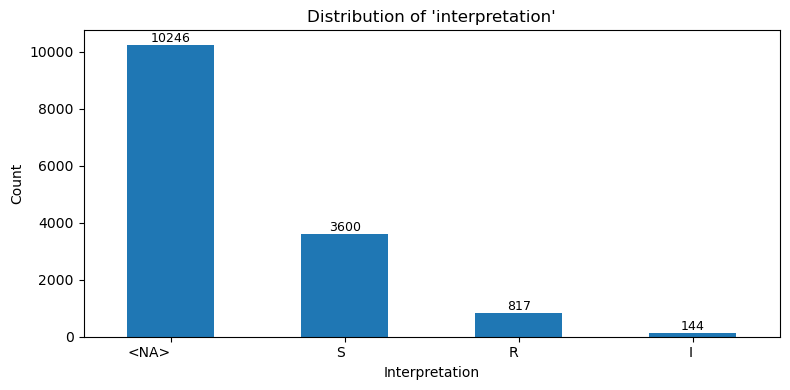

In [46]:
# interpretation distribution
counts = df_cleaned['interpretation'].value_counts(dropna=False)

plt.figure(figsize=(8,4))
ax = counts.plot(kind='bar')

plt.title("Distribution of 'interpretation'")
plt.xlabel("Interpretation")
plt.ylabel("Count")
plt.xticks(rotation=0, ha='right')

for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


#### subject_id

##### Why do we want this analysis: because it reveals if a few patients dominate the dataset.

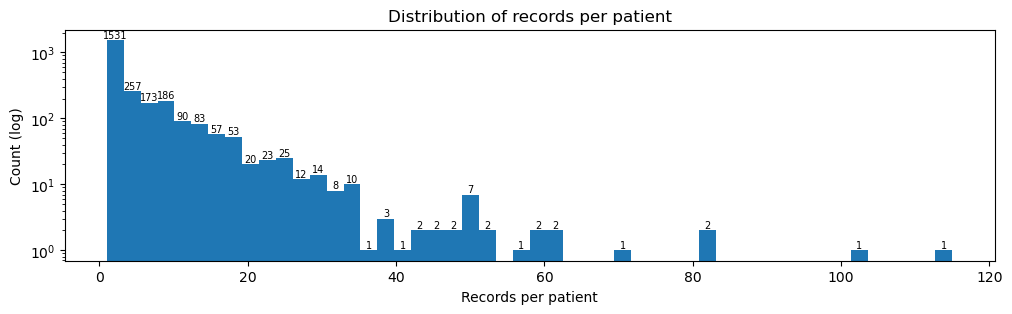

In [47]:
# basic counts
n_patients = df_cleaned['subject_id'].nunique()
records_per_patient = df_cleaned.groupby('subject_id').size().sort_values(ascending=False)

# distribution plot (log-scaled histogram)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,3))
counts, bins, patches = plt.hist(records_per_patient.values, bins=50, log=True)
plt.xlabel('Records per patient')
plt.ylabel('Count (log)')
plt.title('Distribution of records per patient')

# ---- Label ALL non-zero bins ----
for count, left, right in zip(counts, bins[:-1], bins[1:]):
    if count > 0:  # skip empty bins
        bin_center = (left + right) / 2
        plt.text(bin_center, count, f"{int(count)}",
                 ha='center', va='bottom', fontsize=7, color='black')

plt.show()

#### hadm_id (admission-level)

##### Why do we want this analysis: because it is useful to decide whether to do analyses at admission-level or patient-level.

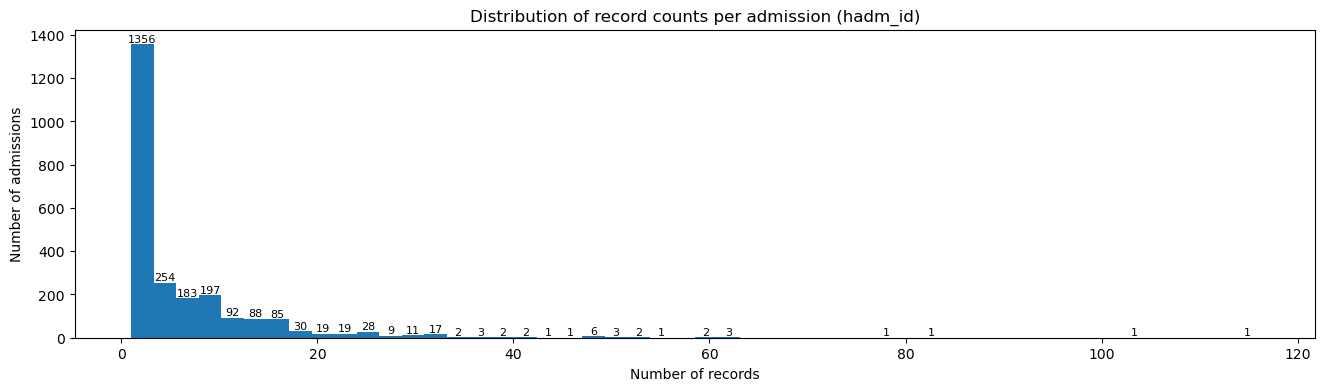

In [48]:
import matplotlib.pyplot as plt

n_adm = df_cleaned['hadm_id'].nunique()
records_per_adm = df_cleaned.groupby('hadm_id').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16,4))
counts, bins, patches = ax.hist(records_per_adm, bins=50)

ax.set_title("Distribution of record counts per admission (hadm_id)")
ax.set_xlabel("Number of records")
ax.set_ylabel("Number of admissions")

# --- Label ALL non-zero bins ---
for count, left, right in zip(counts, bins[:-1], bins[1:]):
    if count > 0:                      # skip empty bins
        bin_center = (left + right) / 2
        ax.text(bin_center, count, f"{int(count)}",
                ha='center', va='bottom', fontsize=8, color='black')

plt.show()

#### charttime (timestamp)

##### Why do we want this analysis: because it detects seasonal outbreaks, lab operational patterns, or time-based QC issues.

2110-02-15 01:37:00 2209-12-20 17:42:00


Text(0.5, 1.0, 'Counts by weekday and hour')

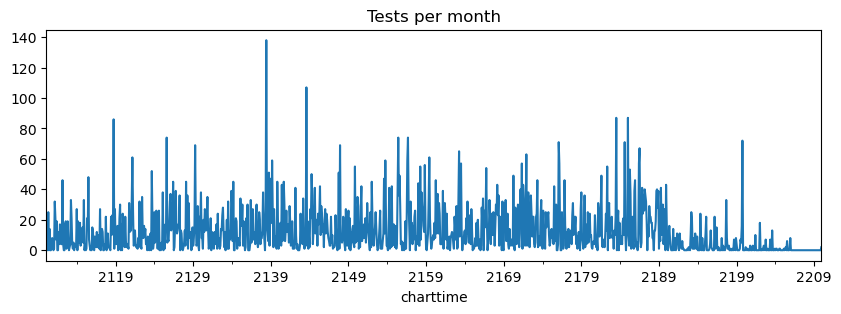

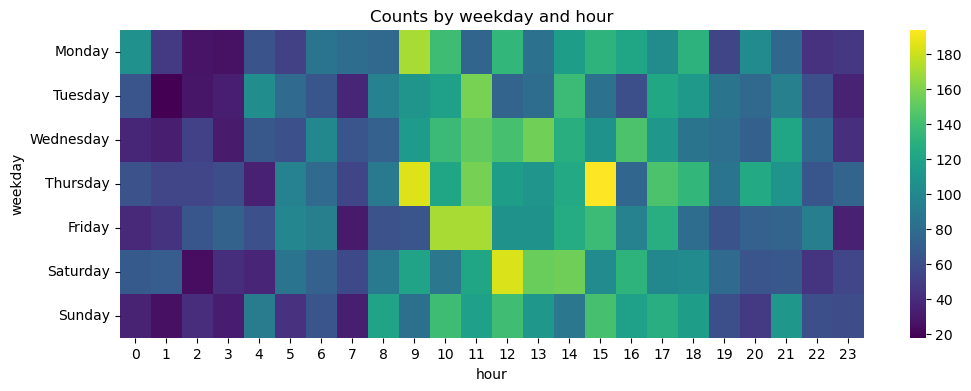

In [52]:
# timespan
print(df_cleaned['charttime'].min(), df_cleaned['charttime'].max())

# counts per month
df_cleaned.set_index('charttime', inplace=False).resample('M').size().plot(figsize=(10,3), title='Tests per month')

# weekday/hour heatmap
df_cleaned['hour'] = df_cleaned['charttime'].dt.hour
df_cleaned['weekday'] = df_cleaned['charttime'].dt.day_name()
pv = df_cleaned.pivot_table(index='weekday', columns='hour', values='test_name', aggfunc='count').fillna(0)
# reorder weekdays
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pv = pv.reindex(order)
import seaborn as sns
plt.figure(figsize=(12,4)); sns.heatmap(pv, cmap='viridis'); plt.title('Counts by weekday and hour')


#### spec_type_desc (specimen type)

##### Why do we want this analysis: because it stratifies analyses by specimen type (URINE vs BLOOD CULTURE differ a lot).

[Text(0, 0, '4706'),
 Text(0, 0, '3205'),
 Text(0, 0, '1761'),
 Text(0, 0, '1184'),
 Text(0, 0, '616'),
 Text(0, 0, '591'),
 Text(0, 0, '556'),
 Text(0, 0, '418'),
 Text(0, 0, '327'),
 Text(0, 0, '196'),
 Text(0, 0, '153'),
 Text(0, 0, '118'),
 Text(0, 0, '106'),
 Text(0, 0, '103'),
 Text(0, 0, '101'),
 Text(0, 0, '92'),
 Text(0, 0, '81'),
 Text(0, 0, '79'),
 Text(0, 0, '52'),
 Text(0, 0, '49')]

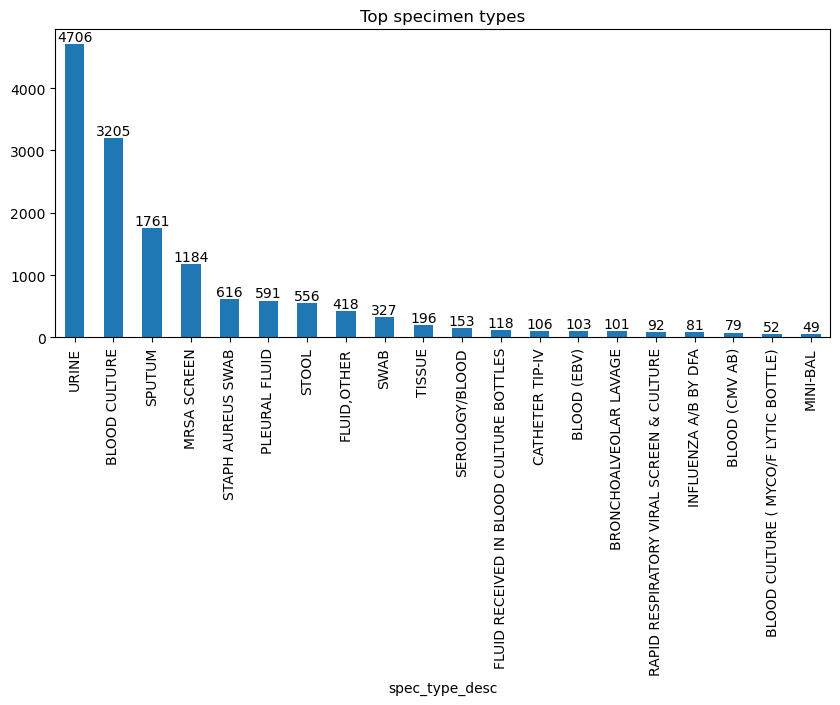

In [53]:
top_spec = df_cleaned['spec_type_desc'].value_counts().head(20)
(ax := top_spec.plot(kind='bar', figsize=(10,4), title='Top specimen types')).bar_label(ax.containers[0])

#### test_name

##### Why do we want this analysis: because different tests have different expected fields (cultures vs screens).

[Text(0, 0, '4554'),
 Text(0, 0, '3043'),
 Text(0, 0, '1174'),
 Text(0, 0, '1167'),
 Text(0, 0, '846'),
 Text(0, 0, '608'),
 Text(0, 0, '332'),
 Text(0, 0, '321'),
 Text(0, 0, '291'),
 Text(0, 0, '204'),
 Text(0, 0, '199'),
 Text(0, 0, '176'),
 Text(0, 0, '171'),
 Text(0, 0, '169'),
 Text(0, 0, '128'),
 Text(0, 0, '109'),
 Text(0, 0, '99'),
 Text(0, 0, '74'),
 Text(0, 0, '70'),
 Text(0, 0, '49'),
 Text(0, 0, '49'),
 Text(0, 0, '47'),
 Text(0, 0, '47'),
 Text(0, 0, '44'),
 Text(0, 0, '41'),
 Text(0, 0, '40'),
 Text(0, 0, '39'),
 Text(0, 0, '39'),
 Text(0, 0, '39'),
 Text(0, 0, '38')]

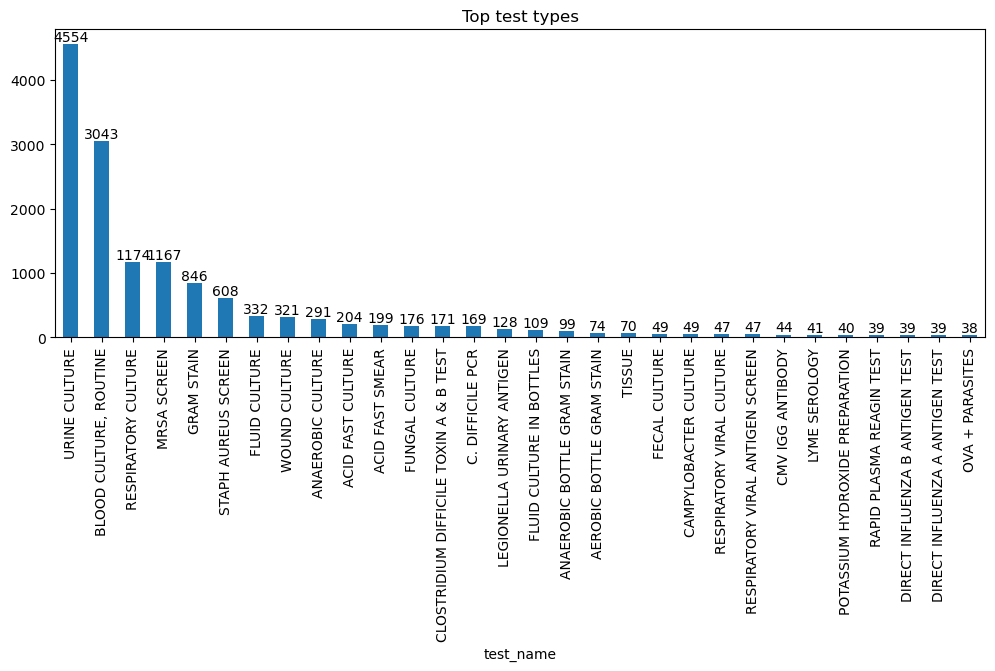

In [54]:
top_test = df_cleaned['test_name'].value_counts().head(30)
(ax := top_test.plot(kind='bar', figsize=(12,4), title='Top test types')).bar_label(ax.containers[0])

#### org_name (organism)

##### Why do we want this analysis: key for organism-specific resistance analysis.

In [55]:
org_counts = df_cleaned['org_name'].value_counts(dropna=True)
org_counts.head(30)

org_name
                                                   9706
ESCHERICHIA COLI                                   1428
STAPH AUREUS COAG +                                 916
KLEBSIELLA PNEUMONIAE                               728
ENTEROCOCCUS SP.                                    255
PSEUDOMONAS AERUGINOSA                              242
PROTEUS MIRABILIS                                   204
STAPHYLOCOCCUS, COAGULASE NEGATIVE                  171
YEAST                                               141
POSITIVE FOR METHICILLIN RESISTANT STAPH AUREUS     132
SERRATIA MARCESCENS                                  78
KLEBSIELLA OXYTOCA                                   69
CITROBACTER FREUNDII COMPLEX                         66
ENTEROBACTER CLOACAE                                 59
STAPHYLOCOCCUS EPIDERMIDIS                           56
GRAM NEGATIVE ROD(S)                                 42
ENTEROBACTER CLOACAE COMPLEX                         37
ENTEROCOCCUS FAECALIS                  

[Text(0, 0, '9706'),
 Text(0, 0, '1428'),
 Text(0, 0, '916'),
 Text(0, 0, '728'),
 Text(0, 0, '255'),
 Text(0, 0, '242'),
 Text(0, 0, '204'),
 Text(0, 0, '171'),
 Text(0, 0, '141'),
 Text(0, 0, '132'),
 Text(0, 0, '78'),
 Text(0, 0, '69'),
 Text(0, 0, '66'),
 Text(0, 0, '59'),
 Text(0, 0, '56'),
 Text(0, 0, '42'),
 Text(0, 0, '37'),
 Text(0, 0, '37'),
 Text(0, 0, '37'),
 Text(0, 0, '34'),
 Text(0, 0, '32'),
 Text(0, 0, '32'),
 Text(0, 0, '28'),
 Text(0, 0, '19'),
 Text(0, 0, '17'),
 Text(0, 0, '12'),
 Text(0, 0, '11'),
 Text(0, 0, '10'),
 Text(0, 0, '10'),
 Text(0, 0, '9')]

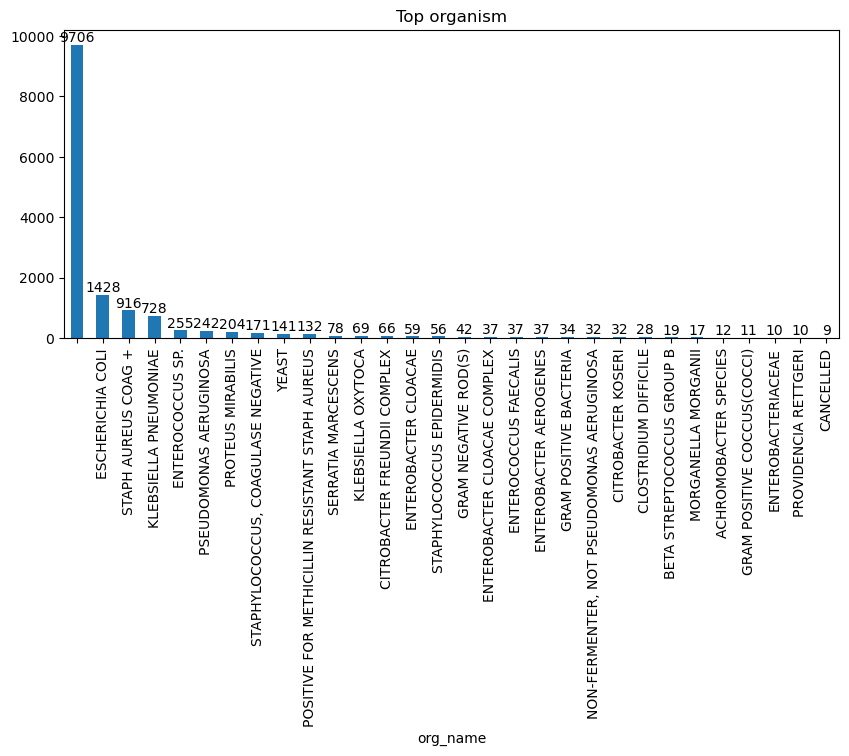

In [56]:
(ax := org_counts.head(30).plot(kind='bar', figsize=(10,4), title='Top organism')).bar_label(ax.containers[0])

In [57]:
prop_missing = df_cleaned['org_name'].isna().mean()
print("org_name missing %:", prop_missing)

org_name missing %: 0.0


#### ab_name (antibiotic)

##### Why do we want this analysis: because it informs us which antibiotic-organism pairs are meaningful for resistance rate tables.

[Text(0, 0, '423'),
 Text(0, 0, '373'),
 Text(0, 0, '271'),
 Text(0, 0, '269'),
 Text(0, 0, '268'),
 Text(0, 0, '267'),
 Text(0, 0, '266'),
 Text(0, 0, '245'),
 Text(0, 0, '236'),
 Text(0, 0, '208'),
 Text(0, 0, '194'),
 Text(0, 0, '191'),
 Text(0, 0, '187'),
 Text(0, 0, '175'),
 Text(0, 0, '164'),
 Text(0, 0, '162'),
 Text(0, 0, '161'),
 Text(0, 0, '144'),
 Text(0, 0, '143'),
 Text(0, 0, '54'),
 Text(0, 0, '38'),
 Text(0, 0, '35'),
 Text(0, 0, '33'),
 Text(0, 0, '27'),
 Text(0, 0, '14'),
 Text(0, 0, '9'),
 Text(0, 0, '4')]

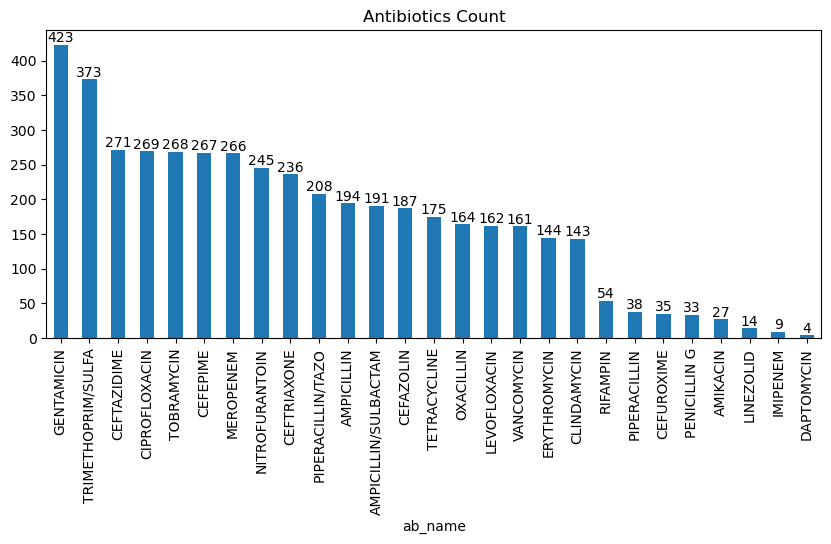

In [58]:
ab_counts = df_cleaned['ab_name'].value_counts(dropna=True)
(ax := ab_counts.plot(kind='bar', figsize=(10,4), title='Antibiotics Count')).bar_label(ax.containers[0])

#### dilution_value / dilution_comparison (MIC)

##### Why do we want this analysis: because it informs us which antibiotic-organism pairs are meaningful for resistance rate tables.

In [59]:
df_cleaned['dilution_value'].value_counts().sort_values(ascending=False)

dilution_value
1.00      1460
0.25       675
4.00       613
0.50       412
16.00      402
2.00       290
8.00       271
32.00      152
64.00      102
0.12        42
128.00      21
256.00      10
0.06         3
512.00       2
3.00         1
Name: count, dtype: int64

[Text(0, 0, '3'),
 Text(0, 0, '42'),
 Text(0, 0, '675'),
 Text(0, 0, '412'),
 Text(0, 0, '1460'),
 Text(0, 0, '290'),
 Text(0, 0, '1'),
 Text(0, 0, '613'),
 Text(0, 0, '271'),
 Text(0, 0, '402'),
 Text(0, 0, '152'),
 Text(0, 0, '102'),
 Text(0, 0, '21'),
 Text(0, 0, '10'),
 Text(0, 0, '2')]

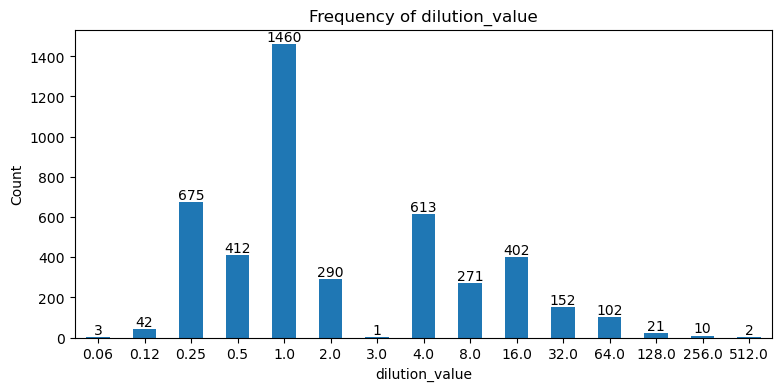

In [60]:
(ax := df_cleaned['dilution_value'].value_counts().
                            sort_index(ascending=True).
                            plot(
                                kind='bar', 
                                figsize=(9,4), 
                                rot = 0,
                                xlabel = "dilution_value", 
                                ylabel = "Count", 
                                title = "Frequency of dilution_value"
                                )).bar_label(ax.containers[0])

#### interpretation (S/I/R)

##### Why do we want this analysis: because it informs us about central outcome variable for susceptibility analysis.

In [61]:
# ax = counts[['S','I','R']].sort_values(by='R', ascending=False).plot(
#     kind='barh',
#     stacked=True,
#     figsize=(12,10),
#     color=['green', 'orange', 'red']
# )

# # Add labels only for non-zero segments
# for container in ax.containers:
#     for bar in container:
#         width = bar.get_width()  # horizontal bar
#         if width > 0:
#             ax.text(
#                 bar.get_x() + width/2,  # x position: center of segment
#                 bar.get_y() + bar.get_height()/2,  # y position: vertical center
#                 f'{int(width)}',  # label text
#                 ha='center',
#                 va='center',
#             )

# plt.xlabel("Number of isolates")
# plt.title("Antibiotics by resistance counts (R)")
# plt.gca().invert_yaxis()  # largest R on top
# plt.show()

#### How to interpret the antibiotic resistance chart

- **S (Susceptible)**: High S means the drug is likely effective. <span style="font-size:0.7em">Proportion of isolates that are effectively inhibited by the antibiotic.</span>
- **I (Intermediate)**: The antibiotic may work at higher doses or in certain body sites. <span style="font-size:0.7em">Proportion of isolates with reduced susceptibility.</span>
- **R (Resistant)**: High R indicates the drug is unlikely to be effective. <span style="font-size:0.7em">Proportion of isolates not inhibited by the antibiotic.</span>

**Reading the chart:**  
- Each horizontal bar shows the distribution of S, I, and R for a specific antibiotic.  
- Bars sorted by **R** highlight antibiotics with the highest resistance.  
- Longer green segments → more effective; longer red segments → higher resistance risk.

#### technician_id

##### Why do we want this analysis: because it detects lab/analyst-level systematic differences.

In [62]:
import matplotlib.pyplot as plt

# Get raw counts of technician's QC results
qc_by_tech = df.groupby('technician_id')['qc_flag'].value_counts().unstack().fillna(0)

# Sort by QC_FAIL count
top_techs = qc_by_tech.sort_values('QC_FAIL', ascending=False).head(30)

# Plot bar chart with raw counts
ax = top_techs[['QC_OK', 'QC_WARN', 'QC_FAIL']].plot(
    kind='barh',
    stacked=True,
    figsize=(12, 9),
    color=['green', 'orange', 'red']
)

plt.xlabel("Raw count of QC results")
plt.title("QC performance by top 30 technicians (sorted by QC_FAIL)")
plt.legend(title="QC flag")
plt.gca().invert_yaxis()  # Highest QC_FAIL on top

# Add raw counts inside each segment
for container in ax.containers:
    for bar in container:
        width = bar.get_width()
        if width > 0:
            ax.text(
                bar.get_x() + width/2,
                bar.get_y() + bar.get_height()/2,
                f'{int(width)}',  # Show raw count as integer
                ha='center',
                va='center'
            )

plt.show()

KeyError: 'QC_FAIL'

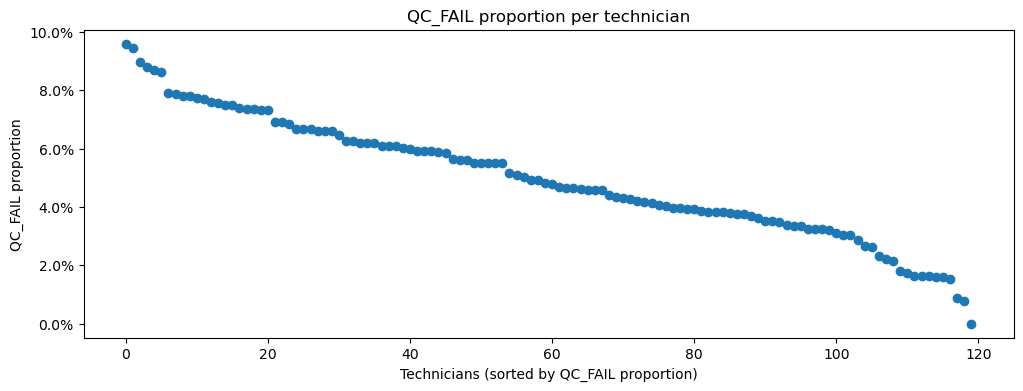

In [ ]:


# Compute proportions (each row sums to total QC records for that technician)
qc_prop = qc_by_tech.div(qc_by_tech.sum(axis=1), axis=0)

# Sort technicians by QC_FAIL proportion
qc_fail_sorted = qc_prop['QC_FAIL'].sort_values(ascending=False)

# Scatter plot
plt.figure(figsize=(12,4))
plt.scatter(range(len(qc_fail_sorted)), qc_fail_sorted.values)
plt.xlabel("Technicians (sorted by QC_FAIL proportion)")
plt.ylabel("QC_FAIL proportion")
plt.title("QC_FAIL proportion per technician")

# Format y-axis as percentages
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))  # 1.0 = max value for scaling

plt.show()


#### Organism × Antibiotic susceptibility matrix (heatmap)

##### <b>What we are doing:</b> Compute monthly resistance rates for a single organism–antibiotic pair and plot trend.
##### <b>Why do we want this analysis:</b> To detect emerging resistance over time.

Text(0.5, 1.0, 'Antibiogram (percent susceptible) — top organisms & antibiotics')

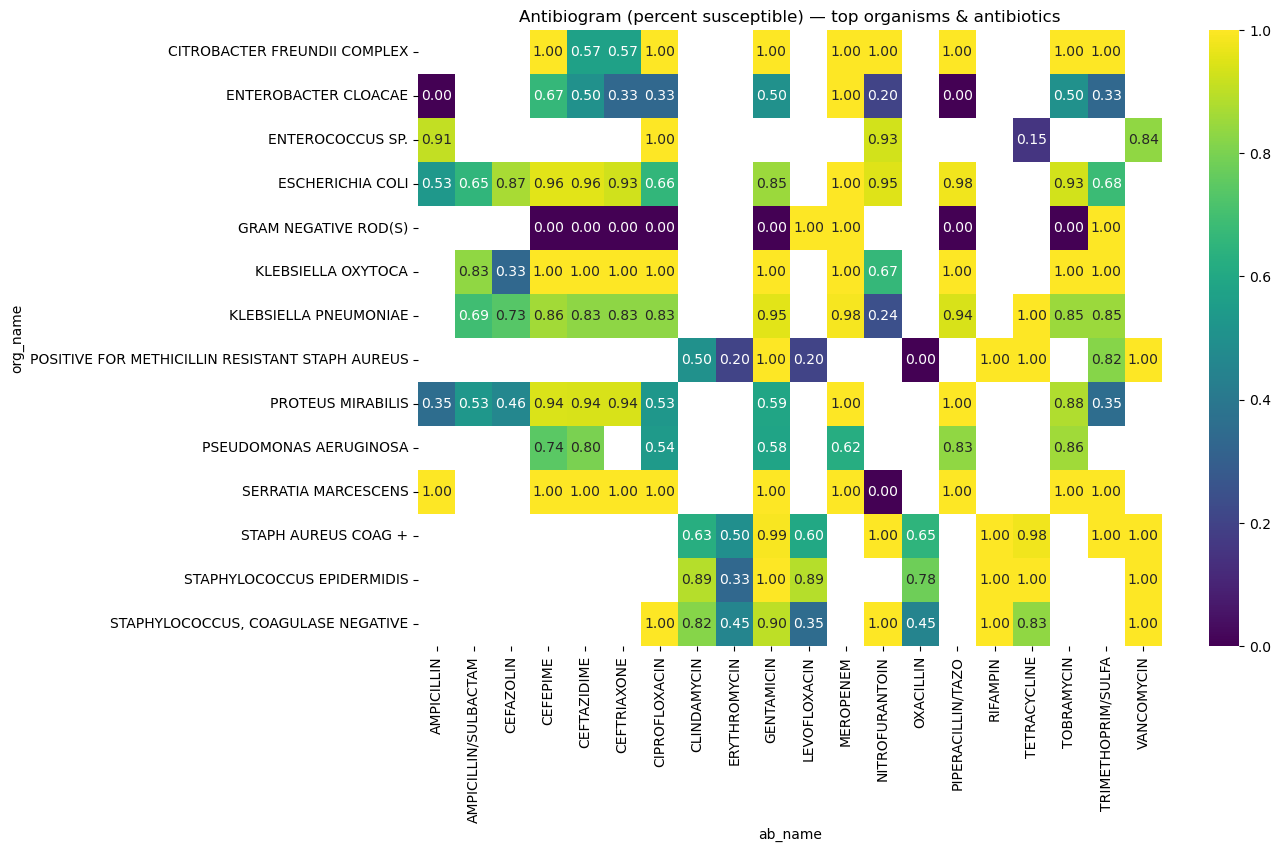

In [ ]:
# Filter to organism + antibiotic rows with interpretation
ab_df = df.dropna(subset=['org_name','ab_name','interpretation']).copy()

# pivot counts
pivot = ab_df.groupby(['org_name','ab_name','interpretation']).size().unstack(fill_value=0)
pivot['TOTAL'] = pivot.sum(axis=1)
pivot = pivot.reset_index()

# percent S
pivot['pct_S'] = pivot.get('S',0) / pivot['TOTAL']

# create heatmap matrix organisms x antibiotics (choose top organisms and top antibiotics)
top_orgs = df['org_name'].value_counts().nlargest(15).index
top_abs = df['ab_name'].value_counts().nlargest(20).index

matrix = pivot[pivot['org_name'].isin(top_orgs) & pivot['ab_name'].isin(top_abs)].pivot(
    index='org_name', columns='ab_name', values='pct_S'
)

# Heatmap
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(matrix, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='viridis')
plt.title('Antibiogram (percent susceptible) — top organisms & antibiotics')

Text(0.5, 1.0, 'Antibiogram (percent R) — top organisms & antibiotics')

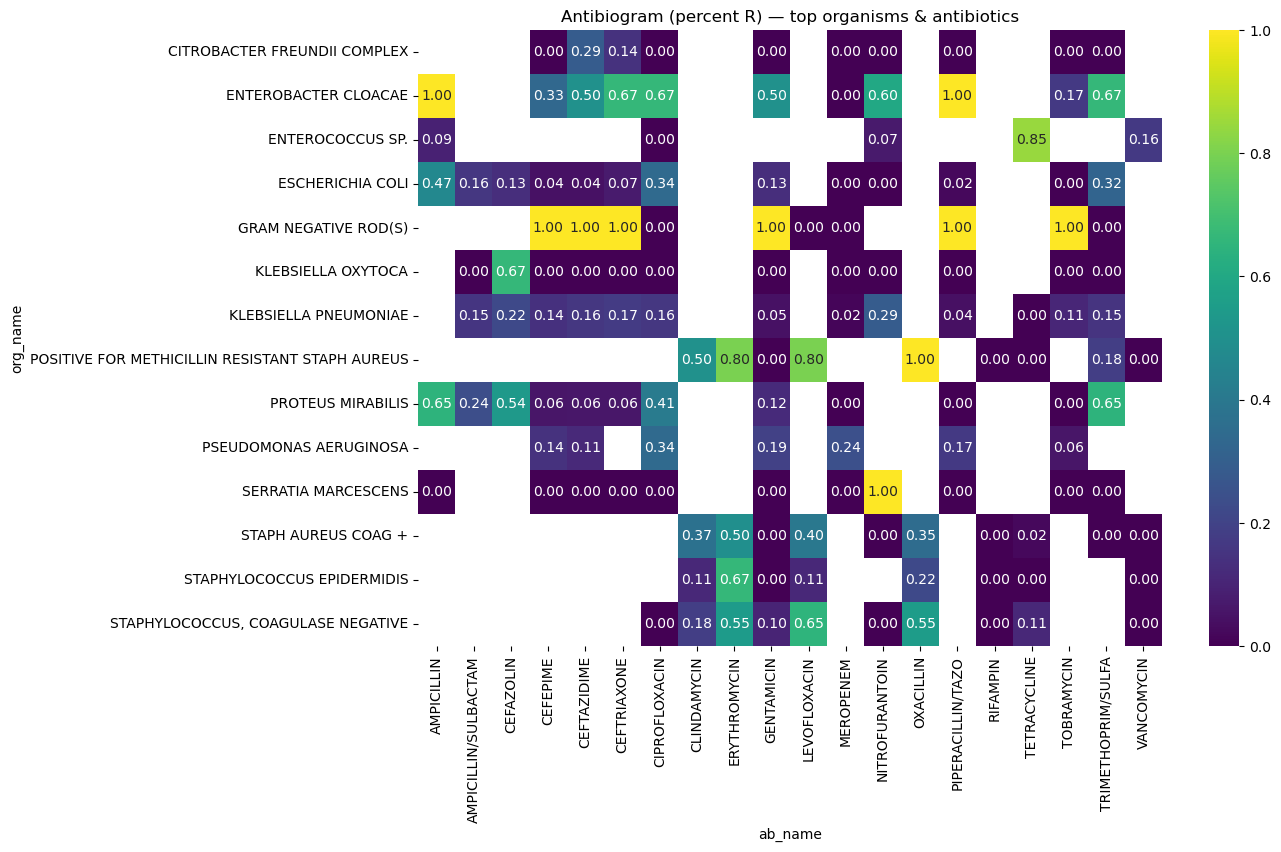

In [ ]:
# Filter to organism + antibiotic rows with interpretation
ab_df = df_cleaned.dropna(subset=['org_name','ab_name','interpretation']).copy()

# pivot counts
pivot = ab_df.groupby(['org_name','ab_name','interpretation']).size().unstack(fill_value=0)
pivot['TOTAL'] = pivot.sum(axis=1)
pivot = pivot.reset_index()

# percent R
pivot['pct_R'] = pivot.get('R',0) / pivot['TOTAL']

# create heatmap matrix organisms x antibiotics (choose top organisms and top antibiotics)
top_orgs = df_cleaned['org_name'].value_counts().nlargest(15).index
top_abs = df_cleaned['ab_name'].value_counts().nlargest(20).index

matrix = pivot[pivot['org_name'].isin(top_orgs) & pivot['ab_name'].isin(top_abs)].pivot(
    index='org_name', columns='ab_name', values='pct_R'
)

# Heatmap
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(matrix, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='viridis')
plt.title('Antibiogram (percent R) — top organisms & antibiotics')

Text(0.5, 1.0, 'Antibiogram (percent I) — top organisms & antibiotics')

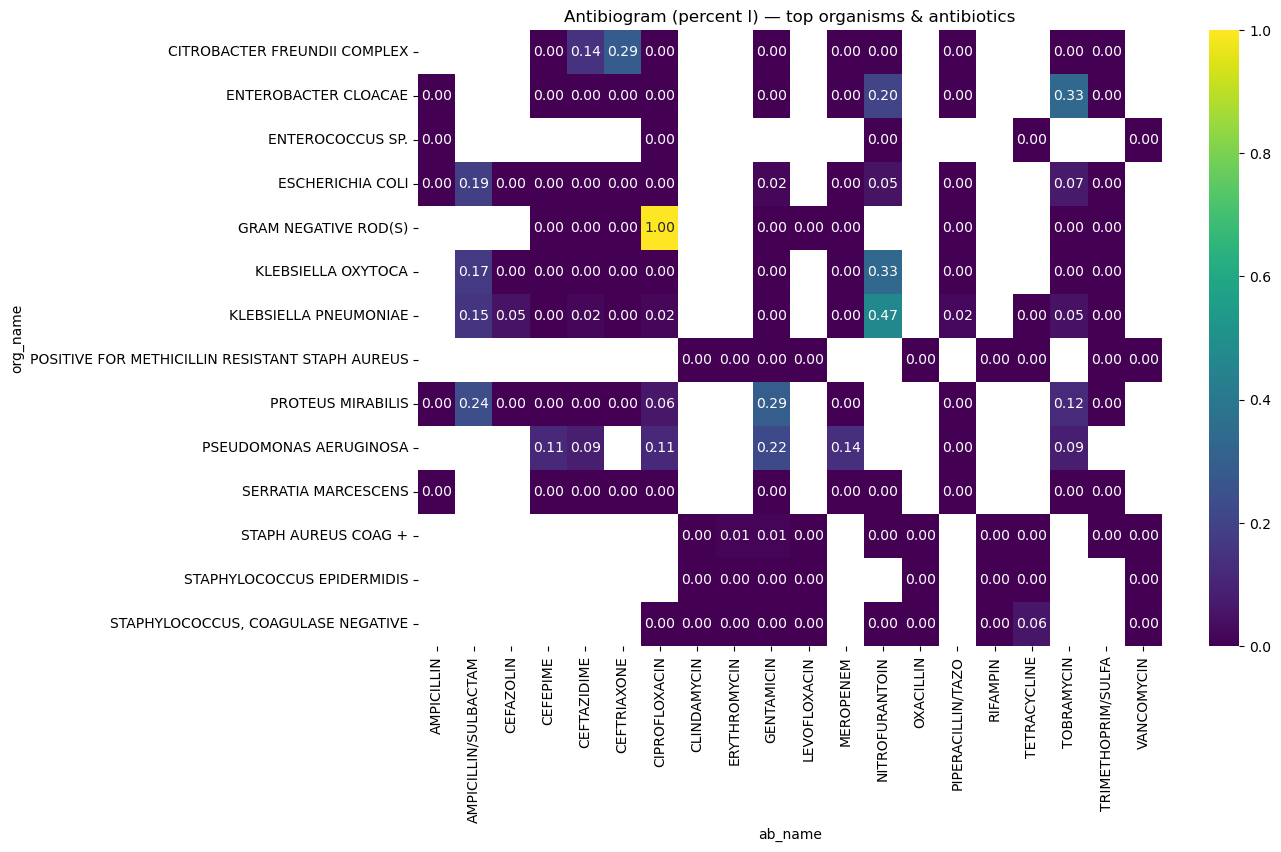

In [ ]:
# Filter to organism + antibiotic rows with interpretation
ab_df = df_cleaned.dropna(subset=['org_name','ab_name','interpretation']).copy()

# pivot counts
pivot = ab_df.groupby(['org_name','ab_name','interpretation']).size().unstack(fill_value=0)
pivot['TOTAL'] = pivot.sum(axis=1)
pivot = pivot.reset_index()

# percent I
pivot['pct_I'] = pivot.get('I',0) / pivot['TOTAL']

# create heatmap matrix organisms x antibiotics (choose top organisms and top antibiotics)
top_orgs = df_cleaned['org_name'].value_counts().nlargest(15).index
top_abs = df_cleaned['ab_name'].value_counts().nlargest(20).index

matrix = pivot[pivot['org_name'].isin(top_orgs) & pivot['ab_name'].isin(top_abs)].pivot(
    index='org_name', columns='ab_name', values='pct_I'
)

# Heatmap
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(matrix, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='viridis')
plt.title('Antibiogram (percent I) — top organisms & antibiotics')

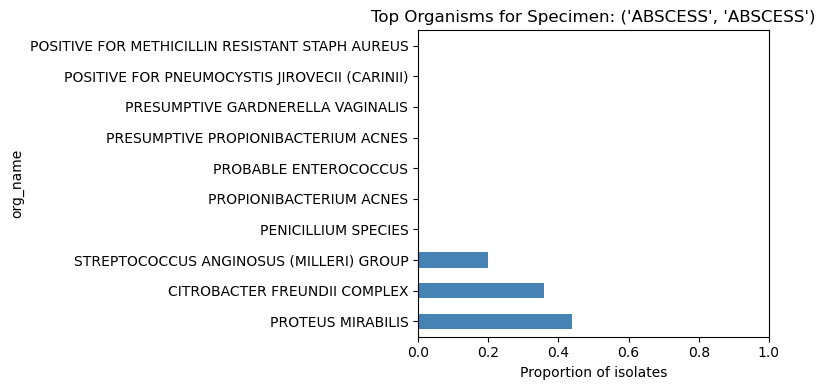

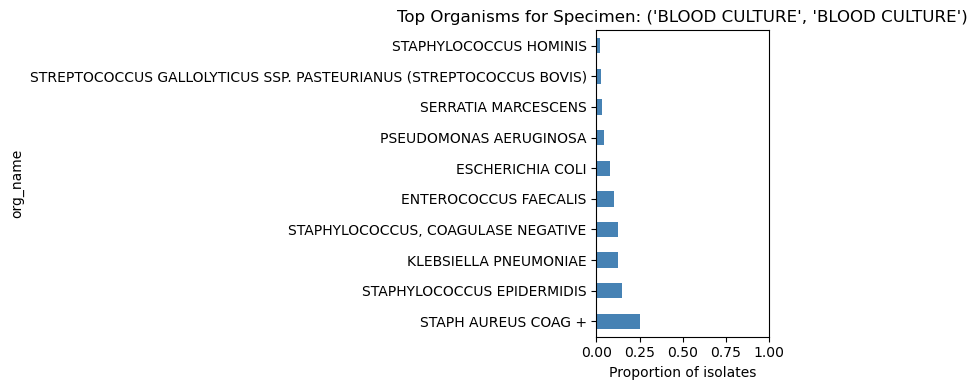

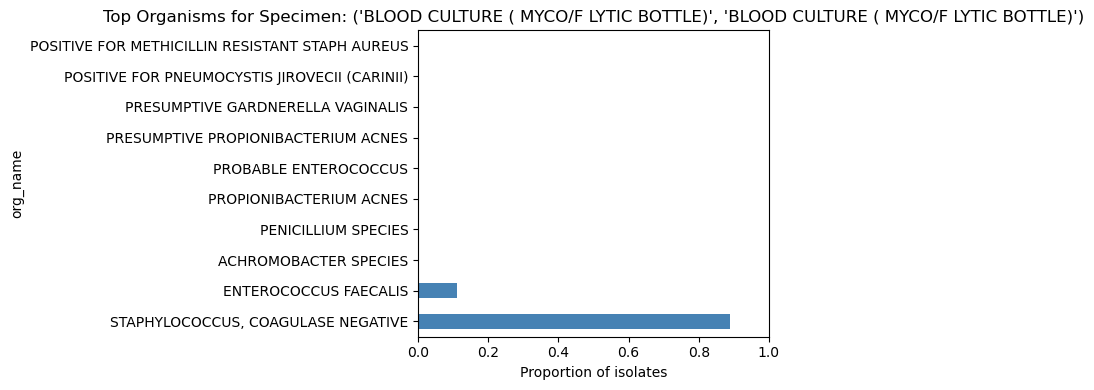

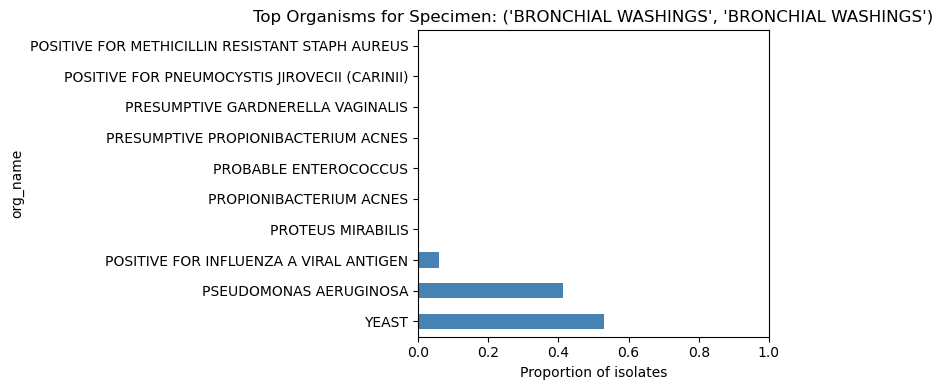

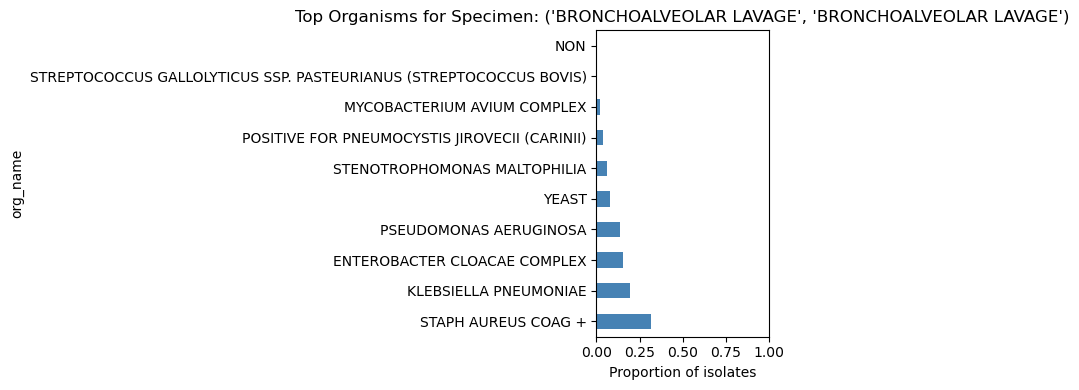

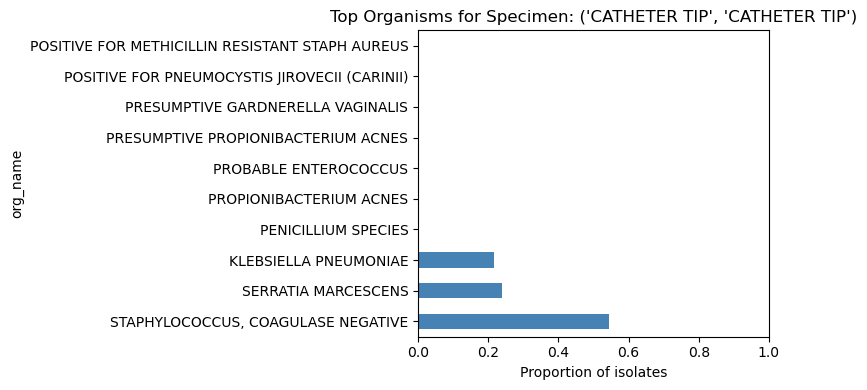

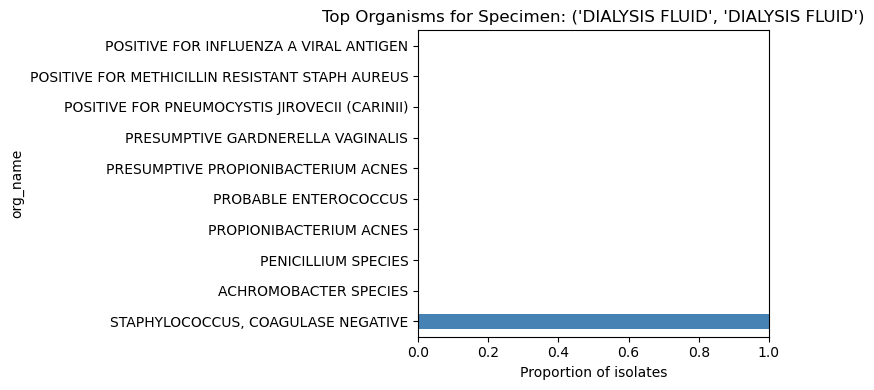

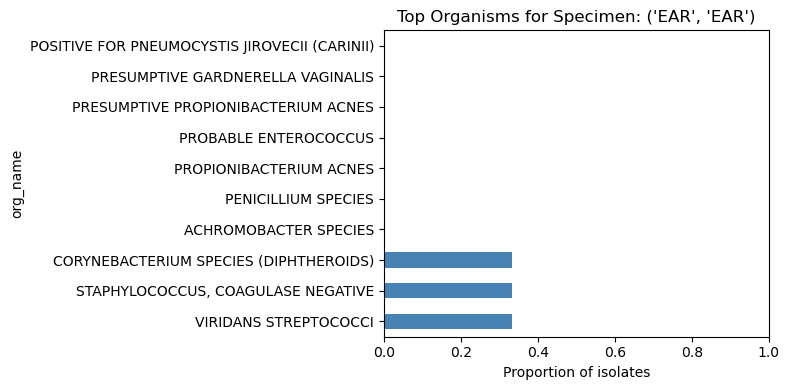

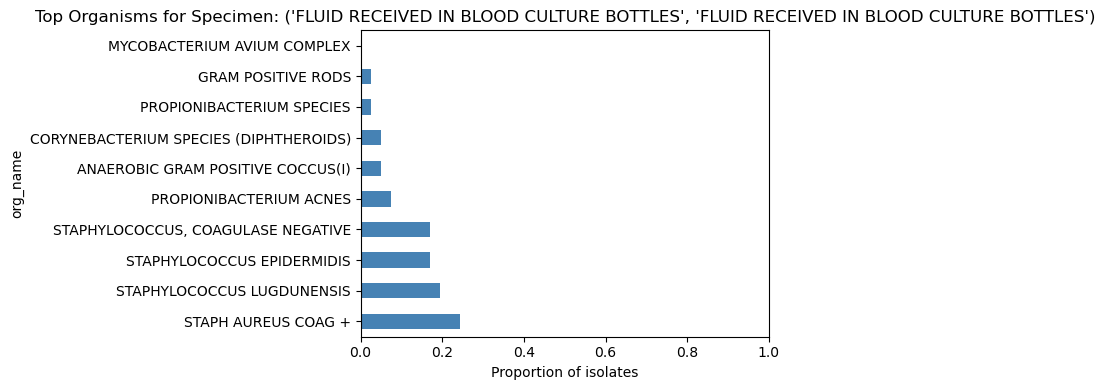

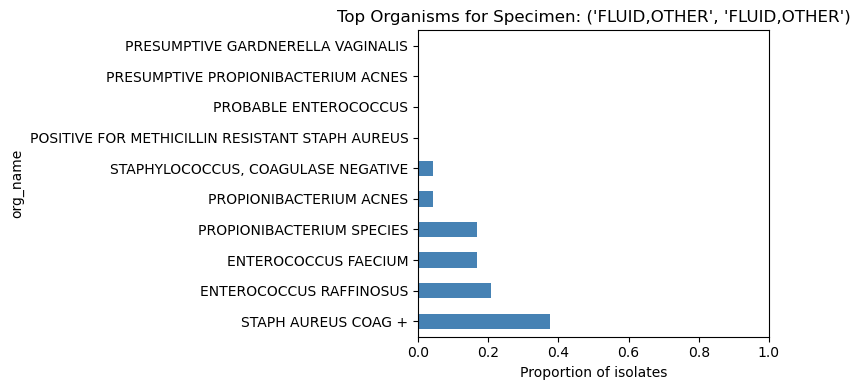

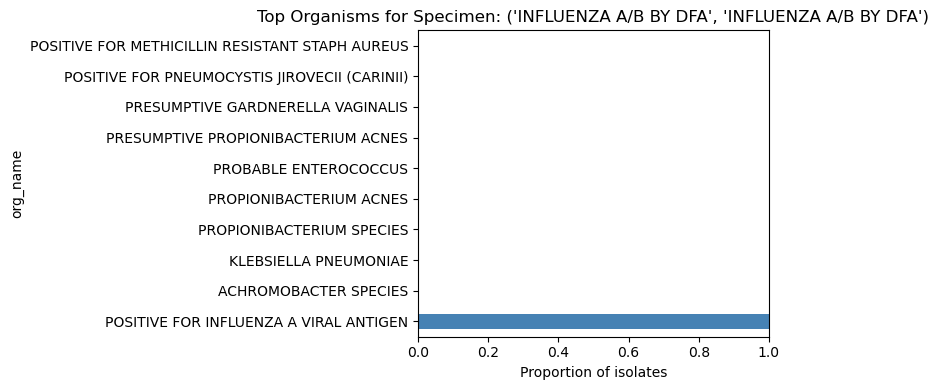

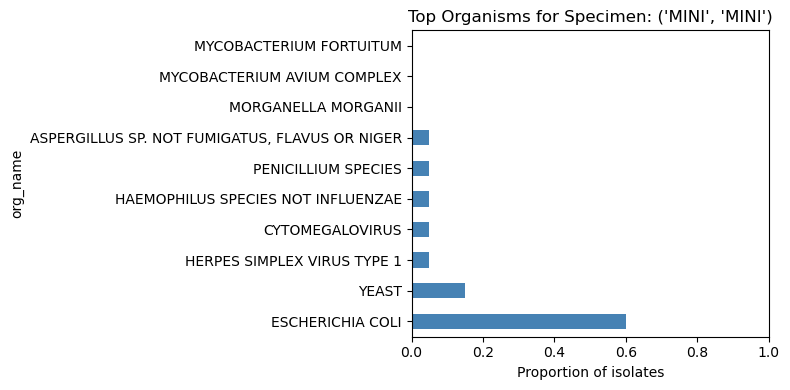

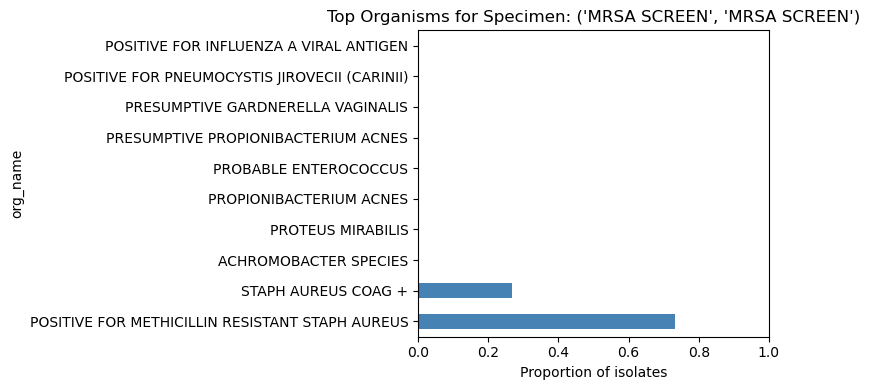

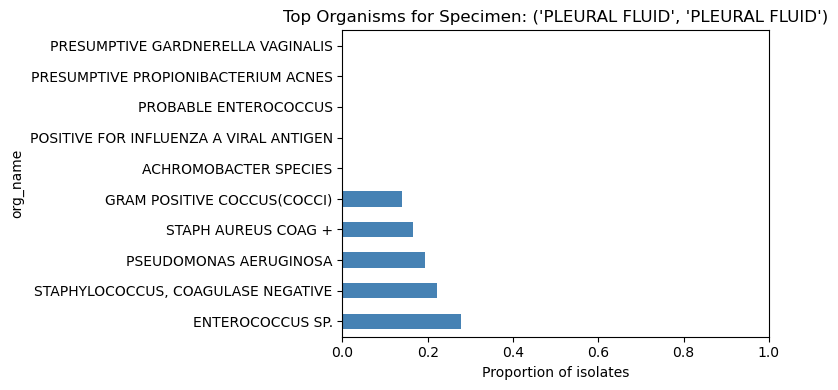

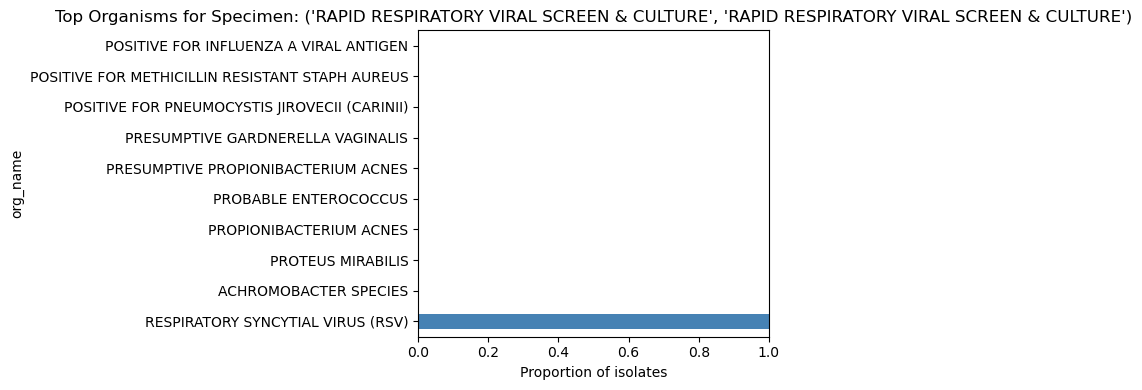

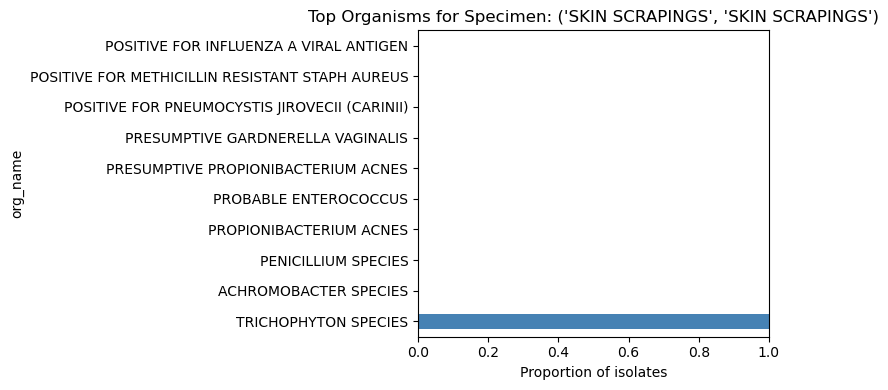

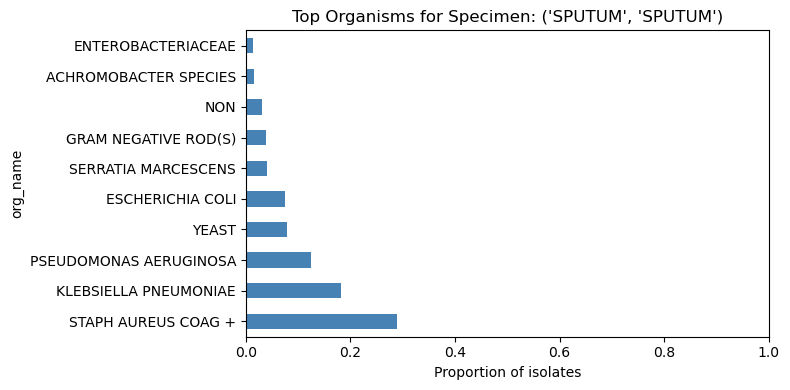

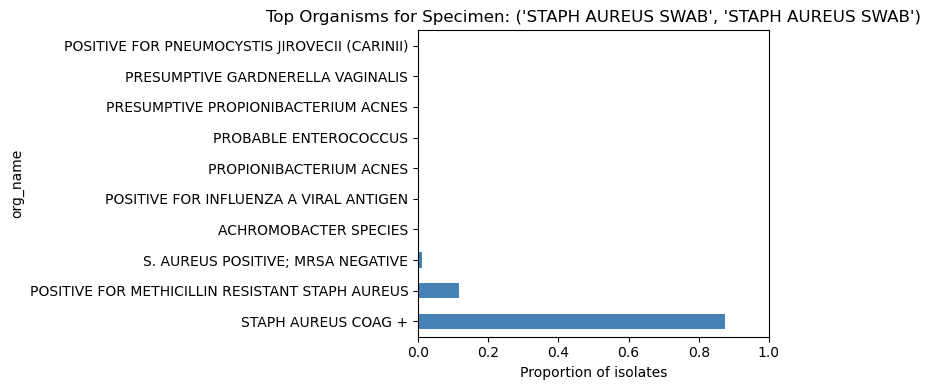

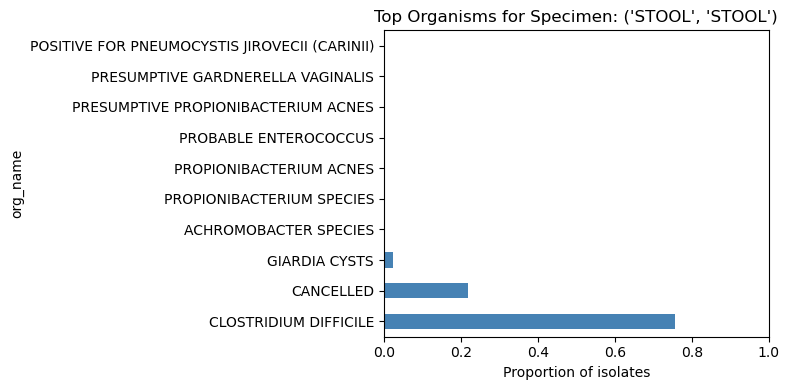

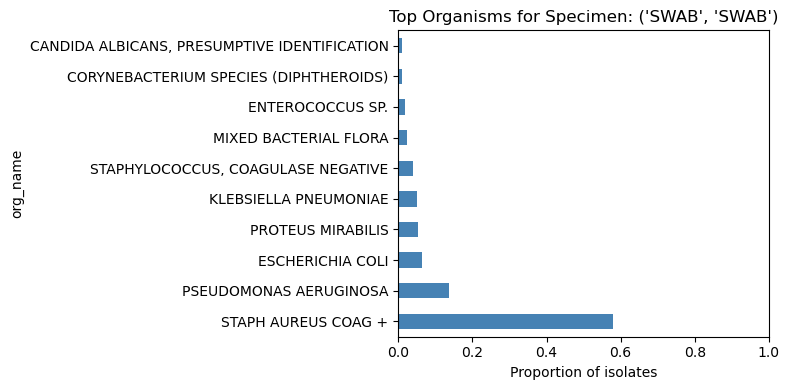

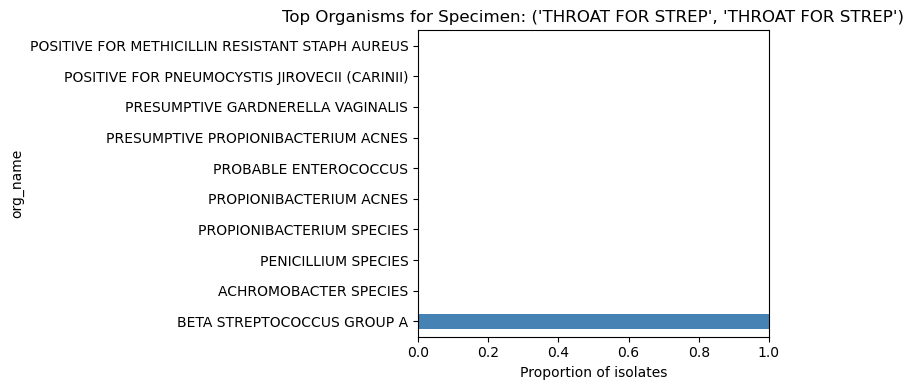

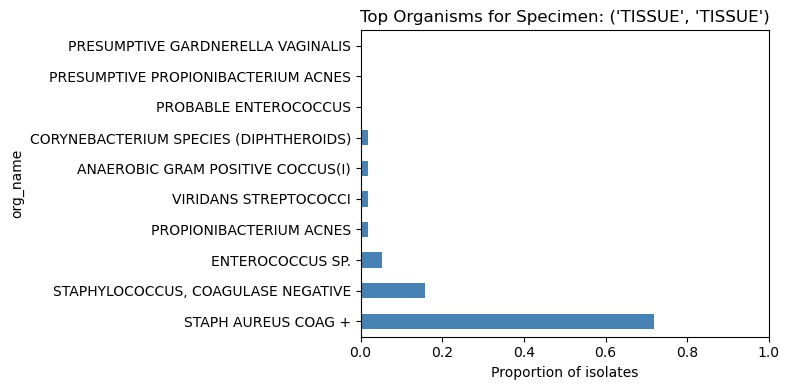

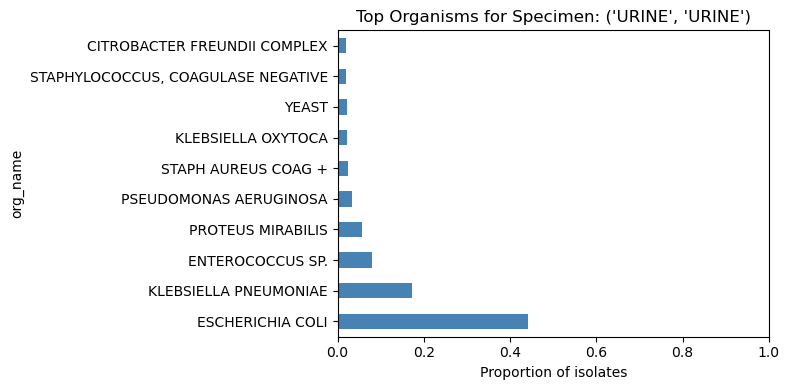

C:\Users\aksha\AppData\Local\Temp\ipykernel_26140\890870203.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 1600x600 with 0 Axes>

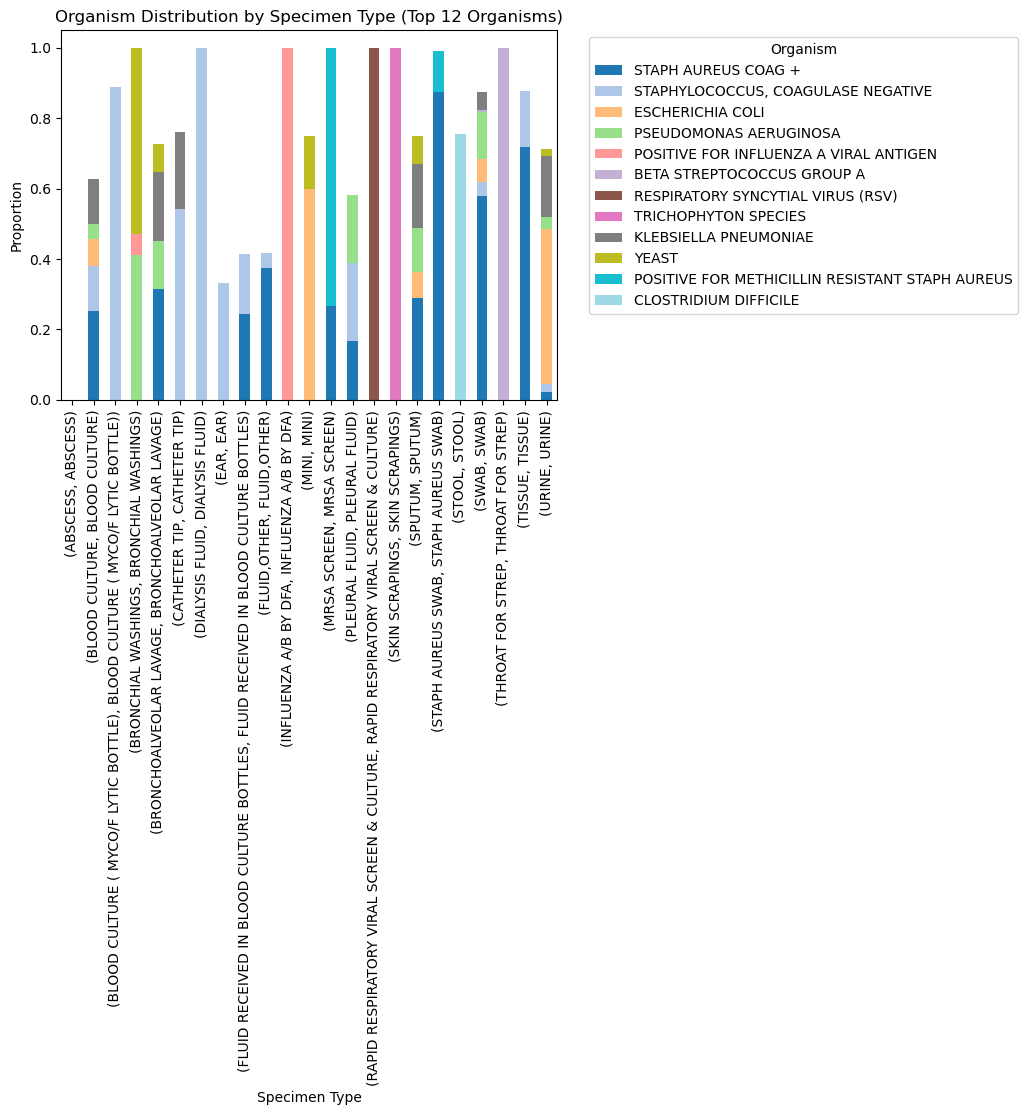

In [ ]:
import matplotlib.pyplot as plt

# Step 1: Make a copy and clean duplicated names
df_cleaned_copy = df_cleaned.copy()
df_cleaned_copy['spec_type_desc'] = df_cleaned_copy['spec_type_desc'].str.split('-').str[0]
df_cleaned_copy['org_name'] = df_cleaned_copy['org_name'].str.split('-').str[0]

# Step 2: Recalculate proportions by specimen and organism
org_by_spec_clean = (
    df_cleaned_copy[df_cleaned_copy['org_name'].notna()]
    .groupby(['spec_type_desc', 'org_name'])
    .size()
    .groupby(level=0)
    .apply(lambda s: s / s.sum())
)

# Step 3: Convert to matrix for plotting
org_matrix_clean = org_by_spec_clean.unstack(fill_value=0)

# --- Option 3: Horizontal bar plots per specimen (top 10 organisms) ---
for spec in org_matrix_clean.index:
    row = org_matrix_clean.loc[spec].sort_values(ascending=False).head(10)
    plt.figure(figsize=(8, 4))
    row.plot(kind='barh', color='steelblue')
    plt.title(f'Top Organisms for Specimen: {spec}')
    plt.xlabel('Proportion of isolates')
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

# --- Option 4: Stacked bar chart of top 12 organisms across all specimens ---
top_orgs_overall = org_matrix_clean.sum(axis=0).nlargest(12).index
stacked_data = org_matrix_clean[top_orgs_overall]

plt.figure(figsize=(16, 6))
stacked_data.plot(kind='bar', stacked=True, colormap='tab20')
plt.ylabel('Proportion')
plt.title('Organism Distribution by Specimen Type (Top 12 Organisms)')
plt.xlabel('Specimen Type')
plt.legend(title='Organism', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()